<a href="https://colab.research.google.com/github/shobhitexp/Cotton_Yarn_Quality_Analysis_Shobhit-Raj/blob/sub-files/Cotton_Yarn_Quality_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cotton Input Quality vs. Yarn Output Quality
### Arvind Limited — 40s Compact NS Spinning Line (Machine ACM1, Achal 2A)

**Prepared by:** Shobhit Raj
**Objective:** Determine whether — and to what extent — the quality of cotton fed into a mixing/blend
determines the quality of the yarn spun from it, using one month of real mill data.

---


## 1. Project Architecture (Plan Before We Touch the Data)

Before writing a single line of analysis code, we lay out the project like a data science
project manager would: scope, data contracts, pipeline stages, and — most importantly —
the risks that could invalidate the whole exercise if ignored.

### 1.1 Business Question
> Does the fibre quality of the cotton blend (mixing/laydown) going into the 40s Compact NS
> frame determine the quality of the yarn tested downstream?

### 1.2 Data Contracts (what we were given)

| File | Grain | Key fields |
|---|---|---|
| `Mixing_Laydown.xlsx` | One row per **cotton lot** inside a **mixing group** (a group = one blend recipe mixed on a date) | LEN, MIC, STR, RD, +B, UNF, SFI, TRASH per lot + a weighted-average row per group |
| `Compact_Yarn.xlsx` | One row per **yarn quality test**, dated | U.C.V%, Thin/Thick/Neps, Total Imp., Hairiness (H., H CV%), Elongation, RKM, CSP, TPI, T.M, Classimat faults |

### 1.3 Pipeline Architecture

```
┌─────────────────────┐   ┌─────────────────────┐
│ Mixing_Laydown.xlsx  │  │ Compact_Yarn.xlsx   │
│ (irregular, stacked  │  │ (test log with std/ │
│  group blocks)       │  │  tolerance header)  │
└──────────┬───────────┘  └───────────┬─────────┘
           │  ETL: custom block parser│  ETL: header split,
           │  → lot_df, group_df      │  dedupe partial retests
           ▼                          ▼
   ┌────────────────┐        ┌────────────────┐
   │  group_df       │        │   yarn_df       │
   │ (blend-level,   │        │ (test-level,    │
   │  1 row/group)   │        │  1 row/test)    │
   └───────┬────────┘        └───────┬────────┘
           │  daily blend series      │
           │  (mean of groups/date)   │
           └────────────┬─────────────┘
                         ▼
              LINKAGE LAYER (the hard part —
              no shared ID between files;
              built on DATE + lag assumption)
                         ▼
                 merged analytical dataset
                         ▼
        EDA → Outlier/Quality checks → Statistics
                         ▼
         ML: multiple regressors, Leave-One-Out CV
         (train R² vs CV R² → over/under-fit diagnosis)
                         ▼
              Findings + explicit caveats
```

### 1.4 Known Risks — Flagged Up Front

We call these out *before* analysis so that later results are read in the right context, not
after the fact to excuse a weak result:

1. **No shared identifier.** Yarn `LOT` codes (e.g. `ACM1-27`) do not match Mixing `GROUP NO.`
   values (e.g. `323`–`401`). There is no bale-to-bobbin traceability field in either file.
   Any cotton→yarn link we build must be **inferred from dates**, not looked up.
2. **Very small yarn sample.** After cleaning there are only ~13 usable yarn tests spanning
   ~1 month, against 53 mixing groups. Any statistical or ML result must be read as
   *exploratory / directional*, not as a validated production model.
3. **Unknown process lead time.** Cotton mixed on day *D* does not become yarn tested on day
   *D*; it passes through blow room → carding → drawing → roving → spinning → conditioning.
   We do not know this lag from the data — we can only test hypotheses about it.
4. **Single machine, single blend recipe, one month.** All groups mix ~100% "VAR-A" type
   cotton on the same machine. We are looking at *variation within a narrow band*, not across
   cotton types — so even a real effect could look weak simply because the *range* of cotton
   quality in this dataset is small.
5. **Yarn quality has other drivers we do not observe**: machine settings, humidity/temperature,
   operator, maintenance state, twist multiplier changes. Cotton is only one input.

These five points are the difference between an honest analysis and an over-claimed one — we
will return to every one of them in the Findings section.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', font_scale=0.95)
plt.rcParams['figure.dpi'] = 110

MIXING_FILE = 'Mixing_Laydown.xlsx'
YARN_FILE   = 'Compact_Yarn.xlsx'

print("Libraries loaded.")


Libraries loaded.


---
## 2. ETL — Turning Two Messy Raw Files Into Clean Tables

### 2.1 Parsing `Mixing_Laydown.xlsx`

This file is **not tabular** in the pandas sense — it is a printed report saved as Excel:
groups of rows stacked vertically, each group with its own header, a variable number of lot
rows, and a "WEIGHTED AVG" footer row. We write a small state-machine parser that walks the
sheet using `GROUP NO.` and `WEIGHTED AVG` as start/end anchors for each block.


In [6]:
raw = pd.read_excel(MIXING_FILE, sheet_name=0, header=None)
print("Raw sheet shape:", raw.shape)
raw.head(10)

Raw sheet shape: (1303, 16)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,NaN,NaN,40s COMP NS - ACM1 - ACHAL 2A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,100% VAR-A Cotton,NaN,NaN,NaN,NO OF BALES,NaN,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GROUP NO. 323,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Cotton Varity,Lot no,LEN,MIC,STR,RD,+B,UNF,SFI,TRASH,BALES,Station,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
5,VAR-A (PRIME),2025/3210,29.26,4.66,30.3,75.2,7.9,83,6.8,2.9,4,STATION-01,NaN,16.0,12.0,NaN
6,BCI VAR-A (SUPER PRIME),2026/8086,29.99,4.54,30.7,75.5,8.1,84,7,2.9,4,STATION-02,NaN,8.0,4.0,NaN
7,BCI VAR-A (SUPER PRIME),2026/8088,29.75,4.52,30.5,74.8,8.1,84.6,6.1,2.9,4,STATION-04,NaN,20.0,16.0,NaN
8,BCI VAR-A (SUPER PRIME),2026/8908,29.44,4.38,30.9,75.6,8.4,84.3,6.6,2.8,4,STATION-03,NaN,24.0,20.0,NaN
9,BCI VAR-A (SUPER PRIME),2026/8909,29.82,4.45,31,76.2,8.2,84.1,6.6,2.8,4,STATION-03,NaN,22.0,18.0,NaN


In [7]:
grp_start = raw.index[raw[0].astype(str).str.contains('GROUP NO', na=False)].tolist()
grp_end   = raw.index[raw[0].astype(str).str.contains('WEIGHTED AVG', na=False)].tolist()
assert len(grp_start) == len(grp_end), "Mismatched group start/end markers — parser assumption broken"
print(f"Found {len(grp_start)} mixing groups in the file.")

lot_rows, group_rows = [], []

for s, e in zip(grp_start, grp_end):
    group_no  = str(raw.loc[s, 0]).split('.')[-1].strip()
    machine   = raw.loc[s - 2, 2]
    cotton_hdr = raw.loc[s - 1, 2]

    for i in range(s + 2, e):
        row = raw.loc[i]
        if pd.isna(row[1]) or row[0] == 'Cotton Varity':
            continue  # blank separator row or repeated header row
        lot_rows.append({
            'group_no': group_no, 'cotton_variety': row[0], 'lot_no': row[1],
            'LEN': row[2], 'MIC': row[3], 'STR': row[4], 'RD': row[5], 'PlusB': row[6],
            'UNF': row[7], 'SFI': row[8], 'TRASH': row[9],
            'bales': row[10], 'station': row[11]
        })

    wr = raw.loc[e]
    group_rows.append({
        'group_no': group_no, 'machine': machine, 'cotton_type_header': cotton_hdr,
        'LEN': wr[2], 'MIC': wr[3], 'STR': wr[4], 'RD': wr[5], 'PlusB': wr[6],
        'UNF': wr[7], 'SFI': wr[8], 'TRASH': wr[9],
        'total_bales': wr[10], 'date': wr[11], 'status': wr[12]
    })

lot_df   = pd.DataFrame(lot_rows)
group_df = pd.DataFrame(group_rows)
group_df['date'] = pd.to_datetime(group_df['date'])

for c in ['LEN','MIC','STR','RD','PlusB','UNF','SFI','TRASH','bales']:
    lot_df[c] = pd.to_numeric(lot_df[c], errors='coerce')
for c in ['LEN','MIC','STR','RD','PlusB','UNF','SFI','TRASH','total_bales']:
    group_df[c] = pd.to_numeric(group_df[c], errors='coerce')

print("lot_df  :", lot_df.shape,  "-> one row per cotton lot used inside a mixing group")
print("group_df:", group_df.shape, "-> one row per mixing group (blend-level weighted average)")
lot_df.head()


Found 53 mixing groups in the file.
lot_df  : (915, 13) -> one row per cotton lot used inside a mixing group
group_df: (53, 14) -> one row per mixing group (blend-level weighted average)


,group_no,cotton_variety,lot_no,LEN,MIC,STR,RD,PlusB,UNF,SFI,TRASH,bales,station
0,323,VAR-A (PRIME),2025/3210,29.26,4.66,30.3,75.2,7.9,83.0,6.8,2.9,4,STATION-01
1,323,BCI VAR-A (SUPER PRIME),2026/8086,29.99,4.54,30.7,75.5,8.1,84.0,7.0,2.9,4,STATION-02
2,323,BCI VAR-A (SUPER PRIME),2026/8088,29.75,4.52,30.5,74.8,8.1,84.6,6.1,2.9,4,STATION-04
3,323,BCI VAR-A (SUPER PRIME),2026/8908,29.44,4.38,30.9,75.6,8.4,84.3,6.6,2.8,4,STATION-03
4,323,BCI VAR-A (SUPER PRIME),2026/8909,29.82,4.45,31.0,76.2,8.2,84.1,6.6,2.8,4,STATION-03


In [8]:

group_df.head()


,group_no,machine,cotton_type_header,LEN,MIC,STR,RD,PlusB,UNF,SFI,TRASH,total_bales,date,status
0,323,40s COMP NS - ACM1 - ACHAL 2A,100% VAR-A Cotton,29.363939,4.476667,30.742424,75.281818,8.184848,83.684848,7.109091,2.848485,66,2026-03-25,OK
1,324,40s COMP NS - ACM1 - ACHAL 2A,100% VAR-A Cotton,29.363939,4.476667,30.742424,75.281818,8.184848,83.684848,7.109091,2.848485,66,2026-03-25,OK
2,325,40s COMP NS - ACM1 - ACHAL 2A,100% VAR-A Cotton,29.338182,4.469091,30.675758,75.296970,8.200000,83.651515,7.039394,2.860606,66,2026-03-26,OK
3,326,40s COMP NS - ACM1 - ACHAL 2A,100% VAR-A Cotton,29.338485,4.471818,30.684848,75.324242,8.218182,83.584848,7.033333,2.863636,66,2026-03-27,OK
4,327,40s COMP NS - ACM1 - ACHAL 2A,100% VAR-A Cotton,29.338485,4.471818,30.684848,75.324242,8.218182,83.584848,7.033333,2.863636,66,2026-03-27,OK


### 2.2 Cleaning notes on the Mixing data

Inspecting `lot_no` and `station` reveals a few real-world data-entry inconsistencies we fix
explicitly rather than silently:


In [9]:
# lot_no separator inconsistency: '2026/8508' vs '2026+8508' (same lot, typo'd separator)
odd_lots = lot_df[lot_df['lot_no'].astype(str).str.contains(r'\+', regex=True)]
print("Lot numbers using '+' instead of '/' (data entry inconsistency):")
print(odd_lots['lot_no'].unique())

lot_df['lot_no_clean'] = lot_df['lot_no'].astype(str).str.replace('+', '/', regex=False)

# station has stray 'amd' text mixed into what should be a station code column upstream (col shift)
print("\nAll station values are otherwise consistently formatted:", lot_df['station'].str.match(r'^STATION-\d+$').mean(), "match rate")

# every group's status flag
print("\nGroup status flags:", group_df['status'].unique(), "-> all groups passed QC as OK")

# sanity check: does the weighted average actually match a bales-weighted mean of the lots?
chk = lot_df.groupby('group_no').apply(
    lambda d: pd.Series({'LEN_check': np.average(d['LEN'], weights=d['bales'])})
, include_groups=False)
comp = group_df.set_index('group_no')[['LEN']].join(chk)
comp['diff'] = (comp['LEN'] - comp['LEN_check']).abs()
print("\nMax discrepancy between reported weighted-avg LEN and recomputed bales-weighted LEN:",
      round(comp['diff'].max(), 4))


Lot numbers using '+' instead of '/' (data entry inconsistency):
['2026+8508' '2025+8418']

All station values are otherwise consistently formatted: 1.0 match rate

Group status flags: ['OK'] -> all groups passed QC as OK

Max discrepancy between reported weighted-avg LEN and recomputed bales-weighted LEN: 0.0


The weighted averages in the file reconcile with an independent bales-weighted recomputation
(max discrepancy ≈ rounding noise), so the group-level weighted-average rows are trustworthy —
we can use them directly as "blend quality" rather than recomputing from lots ourselves.

### 2.3 Parsing `Compact_Yarn.xlsx`

This file has its own quirks: row 0–1 are titles, row 2 is the real header, rows 3–4 are
**STD / Tolerance specification rows** (not data!), and a few rows are **partial retests**
(a second strength sample for the same date+lot with most columns blank).


In [10]:
yraw = pd.read_excel(YARN_FILE, sheet_name=0, header=None)
print("Raw yarn sheet shape:", yraw.shape)

col_names = yraw.iloc[2].tolist()
spec_df   = yraw.iloc[3:5].copy(); spec_df.columns = col_names; spec_df.index = ['STD','Tolerance']
yarn_df   = yraw.iloc[5:].copy();  yarn_df.columns = col_names
yarn_df   = yarn_df.dropna(how='all').reset_index(drop=True)

print("Specification rows (machine standard vs. allowed tolerance):")
spec_df


Raw yarn sheet shape: (20, 27)
Specification rows (machine standard vs. allowed tolerance):


,DATE,Supplier,LOT,U.C.V%,Thin,Thick,Neps,Total Imp.,H.,H CV%,Elong %,Elong % 0.1 P,RKM,0.1 RKm,Mean Count,Count C.V%,Strength C.V%,C.S.P,TPI,T.M,A1A2B1,A3TOD2,Obj. Faults,EFG,H1,H2,Total Classimat
STD,STD,NaN,NaN,12.5,1,15,44,60,4,NaN,4.2,2.94,21,15,NaN,NaN,NaN,NaN,26.6,4.2,60,4,0,0,7,NaN,71
Tolerance,Tol,NaN,NaN,13,2.5,23,59.5,85,4.5,NaN,3.8,2.5,20,14,NaN,NaN,NaN,NaN,(+/-0.6),(+/-0.1),80,6,0,0,9,NaN,95


In [11]:
yarn_df['DATE'] = pd.to_datetime(yarn_df['DATE'])
numeric_cols = [c for c in yarn_df.columns if c not in ('DATE','Supplier','LOT')]
for c in numeric_cols:
    yarn_df[c] = pd.to_numeric(yarn_df[c], errors='coerce')

print("Raw parsed yarn test rows:", yarn_df.shape)
yarn_df[['DATE','Supplier','LOT','U.C.V%','RKM','C.S.P','Total Imp.','Total Classimat']]


Raw parsed yarn test rows: (15, 27)


,DATE,Supplier,LOT,U.C.V%,RKM,C.S.P,Total Imp.,Total Classimat
0,2026-04-01,ACHAL,ACM1/0326-28,13.46,21.38,3172.0,131.4,48.0
1,2026-04-01,ACHAL,ACM1N-29,12.87,21.96,3075.0,92.5,58.0
2,2026-04-09,ACHAL,ACM1-27,13.72,21.15,2991.0,133.8,111.9
3,2026-04-10,ACHAL,ACM1-28,13.48,21.30,2964.0,114.3,129.9
4,2026-04-11,ACHAL,ACM1-30,13.80,20.89,2937.0,136.0,58.0
5,2026-04-15,ACHAL,ACM1-27,13.57,21.26,3017.0,110.0,74.0
6,2026-04-16,ACHAL,ACM1-28,13.44,21.19,3021.0,116.0,67.0
7,2026-04-16,ACHAL,ACM1-28,NaN,20.87,NaN,NaN,NaN
8,2026-04-17,ACHAL,ACM1N-29,12.98,21.53,2983.0,86.0,67.0
9,2026-04-17,ACHAL,ACM1N-29,NaN,22.17,3172.0,NaN,NaN


In [12]:
# Partial retest rows: same DATE+LOT as a prior row, but with most columns (U.C.V%, Total Imp,
# hairiness, classimat...) blank -- these are a second strength-only re-sample, not a new test.
# We keep the FULL test record and drop the partial duplicate, documenting the decision.
is_partial = yarn_df['U.C.V%'].isna() & yarn_df['RKM'].notna()
print(f"Dropping {is_partial.sum()} partial retest rows (only RKM/Elong present, rest blank):")
print(yarn_df.loc[is_partial, ['DATE','LOT']])

yarn_clean = yarn_df.loc[~is_partial].reset_index(drop=True)
print("\nClean, one-row-per-test yarn dataset:", yarn_clean.shape)
yarn_clean[['DATE','LOT','U.C.V%','RKM','C.S.P','Total Imp.','Total Classimat']]


Dropping 2 partial retest rows (only RKM/Elong present, rest blank):
        DATE       LOT
7 2026-04-16   ACM1-28
9 2026-04-17  ACM1N-29

Clean, one-row-per-test yarn dataset: (13, 27)


,DATE,LOT,U.C.V%,RKM,C.S.P,Total Imp.,Total Classimat
0,2026-04-01,ACM1/0326-28,13.46,21.38,3172.0,131.4,48.0
1,2026-04-01,ACM1N-29,12.87,21.96,3075.0,92.5,58.0
2,2026-04-09,ACM1-27,13.72,21.15,2991.0,133.8,111.9
3,2026-04-10,ACM1-28,13.48,21.30,2964.0,114.3,129.9
4,2026-04-11,ACM1-30,13.80,20.89,2937.0,136.0,58.0
5,2026-04-15,ACM1-27,13.57,21.26,3017.0,110.0,74.0
6,2026-04-16,ACM1-28,13.44,21.19,3021.0,116.0,67.0
7,2026-04-17,ACM1N-29,12.98,21.53,2983.0,86.0,67.0
8,2026-04-24,ACM1-28,13.44,21.61,3039.0,85.0,78.0
9,2026-04-24,ACM1N-29,13.09,21.60,2969.0,82.0,51.0


In [13]:
# Any fully-duplicated test rows (exact same DATE+LOT+values)?
dupe_mask = yarn_clean.duplicated(subset=['DATE','LOT'], keep=False)
print("Rows sharing the same DATE+LOT (multiple lots tested same day is expected/normal):",
      dupe_mask.sum())
print(yarn_clean.loc[dupe_mask, ['DATE','LOT']].sort_values('DATE'))


Rows sharing the same DATE+LOT (multiple lots tested same day is expected/normal): 0
Empty DataFrame
Columns: [DATE, LOT]
Index: []


These are **not duplicates** — they are different physical lots (`ACM1-28` vs `ACM1N-29`
etc.) tested on the same calendar date, which is entirely normal for a mill running several
lots per day. No further de-duplication is needed.

### 2.4 Why the two files cannot be joined on an ID

The Yarn file's `LOT` field (`ACM1-27`, `ACM1N-29`, `ACM1/0326-28`) is a **spinning lot / frame
run identifier**, not the Mixing file's `GROUP NO.` (`323`...`401`). We checked directly:


In [14]:
print("Yarn LOT values :", sorted(yarn_clean['LOT'].unique()))
print("Mixing GROUP NO values (min..max):", group_df['group_no'].astype(int).min(), "..",
      group_df['group_no'].astype(int).max())
print("\n-> No overlap possible: these are two independent numbering systems.")
print("   The only field common to both files that can serve as a join key is DATE.")


Yarn LOT values : ['ACM1-27', 'ACM1-28', 'ACM1-30', 'ACM1/0326-28', 'ACM1N-29']
Mixing GROUP NO values (min..max): 323 .. 401

-> No overlap possible: these are two independent numbering systems.
   The only field common to both files that can serve as a join key is DATE.


**Conclusion of the ETL stage:** we now have two clean tables — `group_df` (53 blends,
1 row each, weighted-average fibre properties + mixing date) and `yarn_clean` (13 yarn tests,
1 row each, quality metrics + test date). The two must be linked through **time**, not identity
— that linkage is built in Section 4, after we've looked at each dataset on its own merits.


---
## 3. Exploratory Data Analysis

We look at each dataset independently first — structure, distributions, outliers, and trends
over time — *before* attempting to link them. This avoids the common mistake of jumping to
correlations before understanding what "normal" looks like in each system.

### 3.1 Structural overview


In [15]:
print("=== lot_df (cotton lot level) ===")
lot_df[['LEN','MIC','STR','RD','PlusB','UNF','SFI','TRASH','bales']].describe().round(2)


=== lot_df (cotton lot level) ===


,LEN,MIC,STR,RD,PlusB,UNF,SFI,TRASH,bales
count,915.00,915.00,915.00,915.00,915.00,915.00,915.00,915.00,915.00
mean,29.42,4.47,30.63,75.55,8.14,83.71,7.03,2.88,3.82
std,0.27,0.25,0.31,0.90,0.37,0.53,0.51,0.15,0.81
min,28.84,3.93,30.00,73.80,7.10,82.80,5.80,2.50,1.00
25%,29.21,4.30,30.40,75.00,7.90,83.30,6.60,2.80,4.00
50%,29.45,4.45,30.70,75.20,8.20,83.70,7.10,2.90,4.00
75%,29.65,4.64,30.80,76.30,8.40,84.00,7.50,2.90,4.00
max,30.29,5.13,31.60,78.10,8.90,85.20,8.00,3.20,6.00


In [16]:
print("=== group_df (blend / weighted-average level) ===")
group_df[['LEN','MIC','STR','RD','PlusB','UNF','SFI','TRASH','total_bales']].describe().round(2)


=== group_df (blend / weighted-average level) ===


,LEN,MIC,STR,RD,PlusB,UNF,SFI,TRASH,total_bales
count,53.00,53.00,53.00,53.00,53.00,53.00,53.00,53.00,53.00
mean,29.42,4.47,30.63,75.53,8.15,83.71,7.03,2.88,65.98
std,0.05,0.05,0.05,0.15,0.08,0.12,0.13,0.02,0.14
min,29.34,4.32,30.55,75.28,8.02,83.58,6.64,2.84,65.00
25%,29.40,4.45,30.58,75.42,8.07,83.63,7.01,2.86,66.00
50%,29.42,4.47,30.64,75.50,8.18,83.67,7.04,2.87,66.00
75%,29.44,4.50,30.66,75.63,8.21,83.74,7.10,2.89,66.00
max,29.58,4.53,30.74,75.83,8.25,84.06,7.22,2.93,66.00


In [17]:
print("=== yarn_clean (yarn test level) ===")
yarn_clean[numeric_cols].describe().round(2)


=== yarn_clean (yarn test level) ===


,U.C.V%,Thin,Thick,Neps,Total Imp.,H.,H CV%,Elong %,Elong % 0.1 P,RKM,0.1 RKm,Mean Count,Count C.V%,Strength C.V%,C.S.P,TPI,T.M,A1A2B1,A3TOD2,Obj. Faults,EFG,H1,H2,Total Classimat
count,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00
mean,13.49,3.86,36.52,72.62,113.01,4.03,5.96,3.88,2.28,21.35,14.78,40.87,1.37,5.44,2996.23,26.46,4.14,60.75,1.54,0.23,0.08,5.15,5.77,73.45
std,0.33,2.33,6.87,13.46,20.28,0.24,1.65,0.24,0.22,0.27,0.85,0.48,0.44,2.42,88.99,0.28,0.06,22.52,1.90,0.60,0.28,3.65,8.55,24.70
min,12.87,1.00,27.00,48.00,82.00,3.57,2.70,3.48,1.87,20.89,13.24,40.01,0.70,2.86,2779.00,26.00,4.06,38.00,0.00,0.00,0.00,0.00,0.00,48.00
25%,13.44,2.80,32.00,61.50,92.50,4.03,4.70,3.79,2.15,21.19,14.16,40.58,1.08,4.05,2968.00,26.32,4.11,45.00,0.00,0.00,0.00,3.00,0.00,58.00
50%,13.48,3.00,36.30,75.00,116.00,4.11,6.30,3.85,2.27,21.30,15.05,40.91,1.36,4.89,2991.00,26.40,4.12,55.00,0.00,0.00,0.00,5.00,4.00,67.00
75%,13.79,5.00,41.70,81.00,131.40,4.16,7.00,4.02,2.38,21.53,15.38,41.24,1.49,5.51,3036.00,26.70,4.17,68.00,3.00,0.00,0.00,7.00,8.00,78.00
max,13.86,9.00,48.00,92.30,136.00,4.27,8.10,4.25,2.72,21.96,15.92,41.54,2.20,11.39,3172.00,27.02,4.27,113.90,5.00,2.00,1.00,12.00,30.00,129.90


In [18]:
print("Missing values per column (lot_df):")
print(lot_df.isna().sum()[lambda s: s > 0])
print("\nMissing values per column (group_df):")
print(group_df.isna().sum()[lambda s: s > 0])
print("\nMissing values per column (yarn_clean), top 10:")
print(yarn_clean.isna().sum().sort_values(ascending=False).head(10))


Missing values per column (lot_df):
Series([], dtype: int64)

Missing values per column (group_df):
Series([], dtype: int64)

Missing values per column (yarn_clean), top 10:
DATE          0
Supplier      0
LOT           0
U.C.V%        0
Thin          0
Thick         0
Neps          0
Total Imp.    0
H.            0
H CV%         0
dtype: int64


No missing values in the cotton weighted-average blend data. The yarn file has a handful
of missing hairiness/classimat entries on a couple of test dates — likely instrument
readings not captured for that run — small enough (≤2 of 13 rows per column) that we leave
them as NaN and let downstream statistics/models skip them per-column rather than imputing.

### 3.2 Cotton varieties actually used


cotton_variety
BCI VAR-A (SUPER PRIME)    1857
BCI VAR-A (PRIME)           626
VAR-A (PRIME)               526
ORG CERT-A (OCS)            132
ORG CERT-D                   94
ORG CERT-B                   92
BCI VAR-B (SUPER PRIME)      54
ORG CERT-A (GOTS)            44
REGEN-CERT-A                 32
ORG CERT-C (GOTS)            26
ORG CERT-A (OCS)-CC          14
Name: bales, dtype: int64


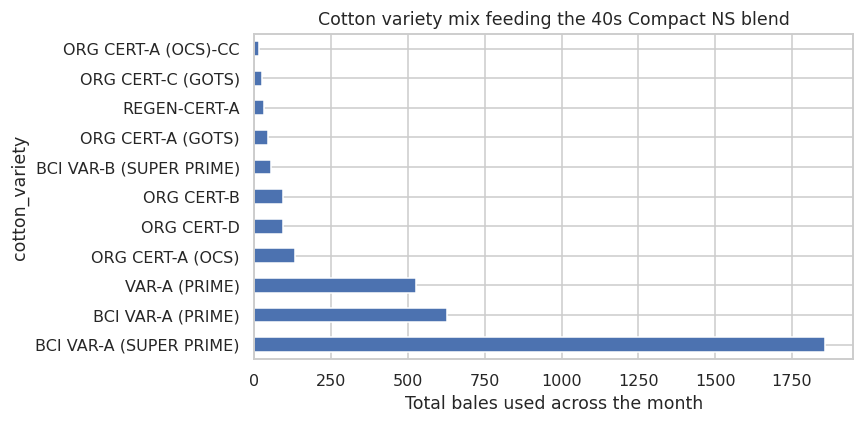

In [19]:
variety_bales = lot_df.groupby('cotton_variety')['bales'].sum().sort_values(ascending=False)
print(variety_bales)

fig, ax = plt.subplots(figsize=(8,4))
variety_bales.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Total bales used across the month')
ax.set_title('Cotton variety mix feeding the 40s Compact NS blend')
plt.tight_layout()
plt.show()


The blend is overwhelmingly **BCI VAR-A (Super Prime)** and **VAR-A (Prime)** cotton, with
small contributions from certified/organic variants (OCS, GOTS, REGEN-CERT). This is a
single-recipe blend repeated with minor lot substitutions — which is exactly why we flagged
"narrow range of cotton quality" as a risk in Section 1.

### 3.3 Distributions of cotton fibre properties (blend / group level)


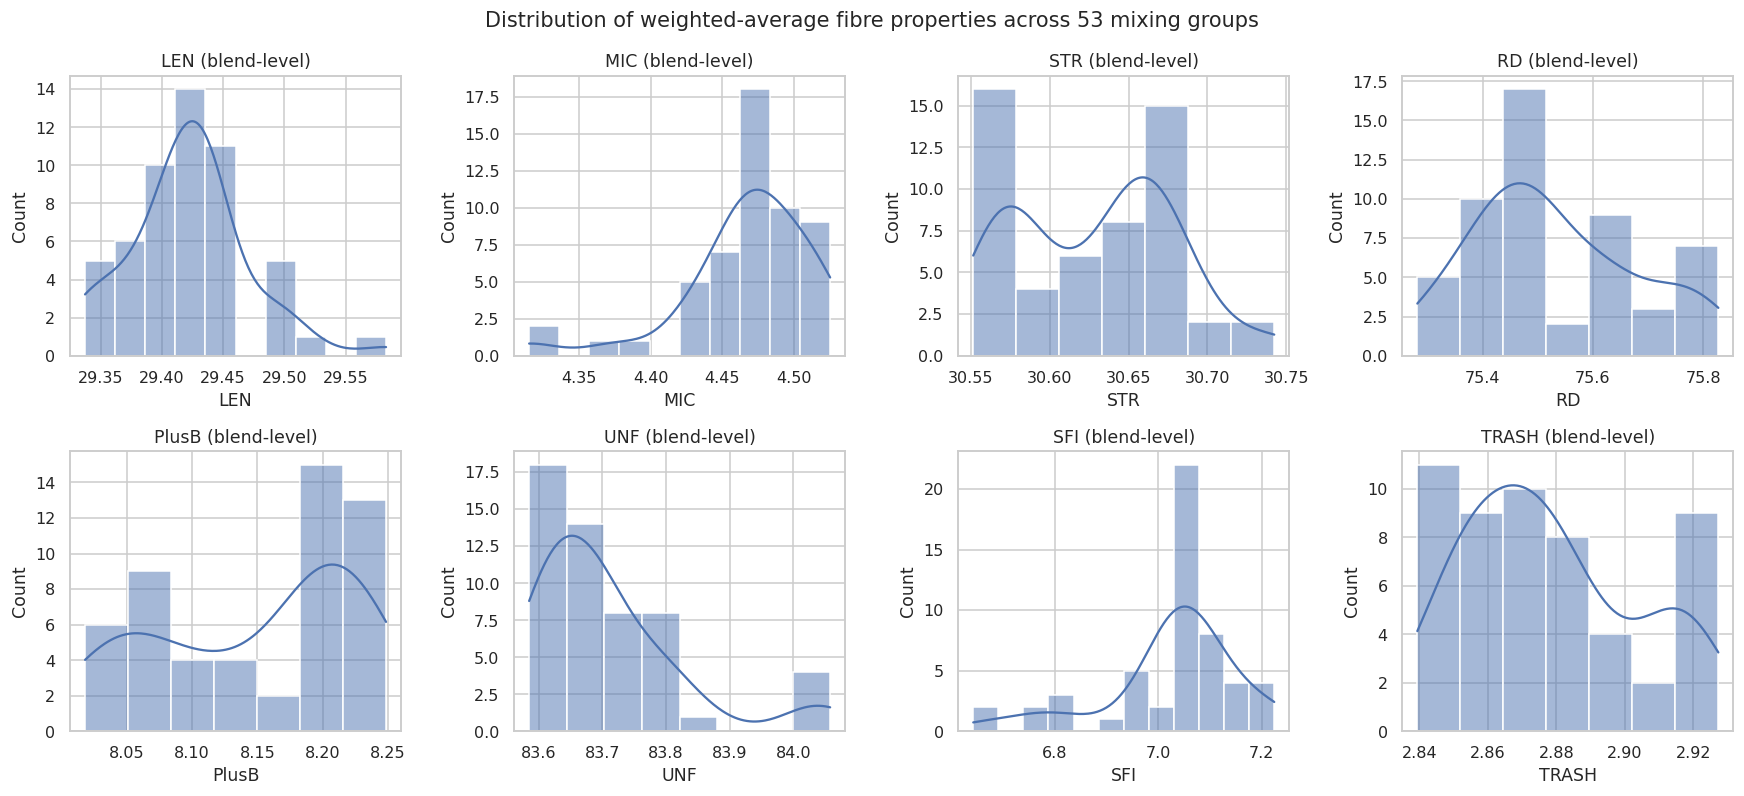

         LEN    MIC     STR      RD  PlusB     UNF    SFI  TRASH
mean  29.421  4.467  30.629  75.529  8.149  83.708  7.026  2.878
std    0.048  0.046   0.050   0.148  0.077   0.118  0.130  0.025
min   29.337  4.315  30.552  75.282  8.018  83.585  6.642  2.839
max   29.583  4.525  30.742  75.827  8.248  84.058  7.224  2.927


In [20]:
fibre_cols = ['LEN','MIC','STR','RD','PlusB','UNF','SFI','TRASH']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, fibre_cols):
    sns.histplot(group_df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'{col} (blend-level)')
plt.tight_layout()
plt.suptitle('Distribution of weighted-average fibre properties across 53 mixing groups', y=1.03)
plt.show()

print(group_df[fibre_cols].agg(['mean','std','min','max']).round(3))


Every property occupies a **tight band**: e.g. MIC ranges roughly 4.3–4.5, STR roughly
30.6–30.8 g/tex, TRASH roughly 2.8–2.9%. This confirms visually what the variety mix already
told us — the mill is running one consistent recipe, so any "cotton quality → yarn quality"
relationship we find will necessarily be about *small* fluctuations, not large swings.

### 3.4 Outlier detection — cotton lots

We check for outlier **lots** (not just groups) using both IQR and Z-score, since an unusual
individual bale could get diluted into a group average and hidden.


In [21]:
def iqr_outliers(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return (s < lo) | (s > hi)

outlier_report = {}
for col in fibre_cols:
    iqr_flag = iqr_outliers(lot_df[col])
    z_flag = (np.abs(stats.zscore(lot_df[col], nan_policy='omit')) > 3)
    outlier_report[col] = {'IQR_outliers': int(iqr_flag.sum()), 'Zscore_gt3': int(z_flag.sum())}

report_df = pd.DataFrame(outlier_report).T
print(report_df)

print("\nTRASH is measured/rounded to a handful of discrete values, so its IQR is very narrow:")
print(lot_df['TRASH'].value_counts().sort_index())


       IQR_outliers  Zscore_gt3
LEN               0           4
MIC               0           0
STR              12          12
RD                0           0
PlusB            19           0
UNF              24           0
SFI               0           0
TRASH           202           0

TRASH is measured/rounded to a handful of discrete values, so its IQR is very narrow:
TRASH
2.5     27
2.6     28
2.7     83
2.8    241
2.9    322
3.0     67
3.1    111
3.2     36
Name: count, dtype: int64


**Important nuance on the IQR counts above:** TRASH, PlusB and UNF are recorded to coarse
rounding (TRASH mostly sits at 2.5-3.2 in 0.1 steps), which makes their inter-quartile range
tiny (Q1=2.8, Q3=2.9 for TRASH) — so the standard `1.5*IQR` rule flags a *large fraction* of
lots as "outliers" purely because the distribution is naturally clustered, not because those
lots are anomalous. The **Z-score** column (which uses the full spread, not the narrow middle
50%) is the more trustworthy check here, and it flags almost nothing. We treat the IQR column
as a caution about applying textbook outlier rules blindly to coarsely-rounded industrial data,
not as evidence of 202 bad cotton lots.


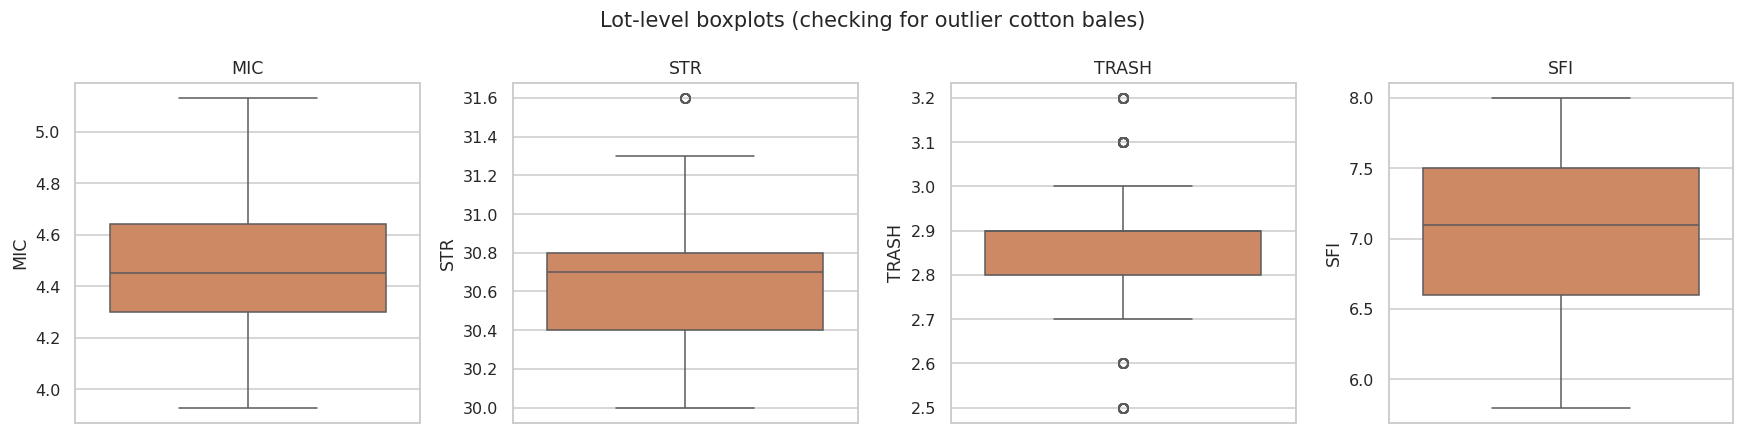

Highest-trash lots in the month:
    group_no cotton_variety     lot_no  TRASH   MIC   STR
100      328     ORG CERT-D  2025/5444    3.2  3.97  31.6
118      332     ORG CERT-D  2025/5444    3.2  3.97  31.6
135      333     ORG CERT-D  2025/5444    3.2  3.97  31.6
152      334     ORG CERT-D  2025/5444    3.2  3.97  31.6
169      335     ORG CERT-D  2025/5444    3.2  3.97  31.6


In [22]:
fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, col in zip(axes, ['MIC','STR','TRASH','SFI']):
    sns.boxplot(y=lot_df[col], ax=ax, color='#DD8452')
    ax.set_title(col)
plt.suptitle('Lot-level boxplots (checking for outlier cotton bales)')
plt.tight_layout()
plt.show()

worst_trash = lot_df.nlargest(5, 'TRASH')[['group_no','cotton_variety','lot_no','TRASH','MIC','STR']]
print("Highest-trash lots in the month:")
print(worst_trash)


A handful of individual lots sit at the edges (e.g. a few higher-trash or higher-MIC bales),
but nothing extreme enough to be a data error — these look like genuine natural bale-to-bale
variation, and none of them dominate a group average since each group blends the bales of
many stations together. We do **not** remove any lots; we flag this and move on.

### 3.5 Cotton property trends over time


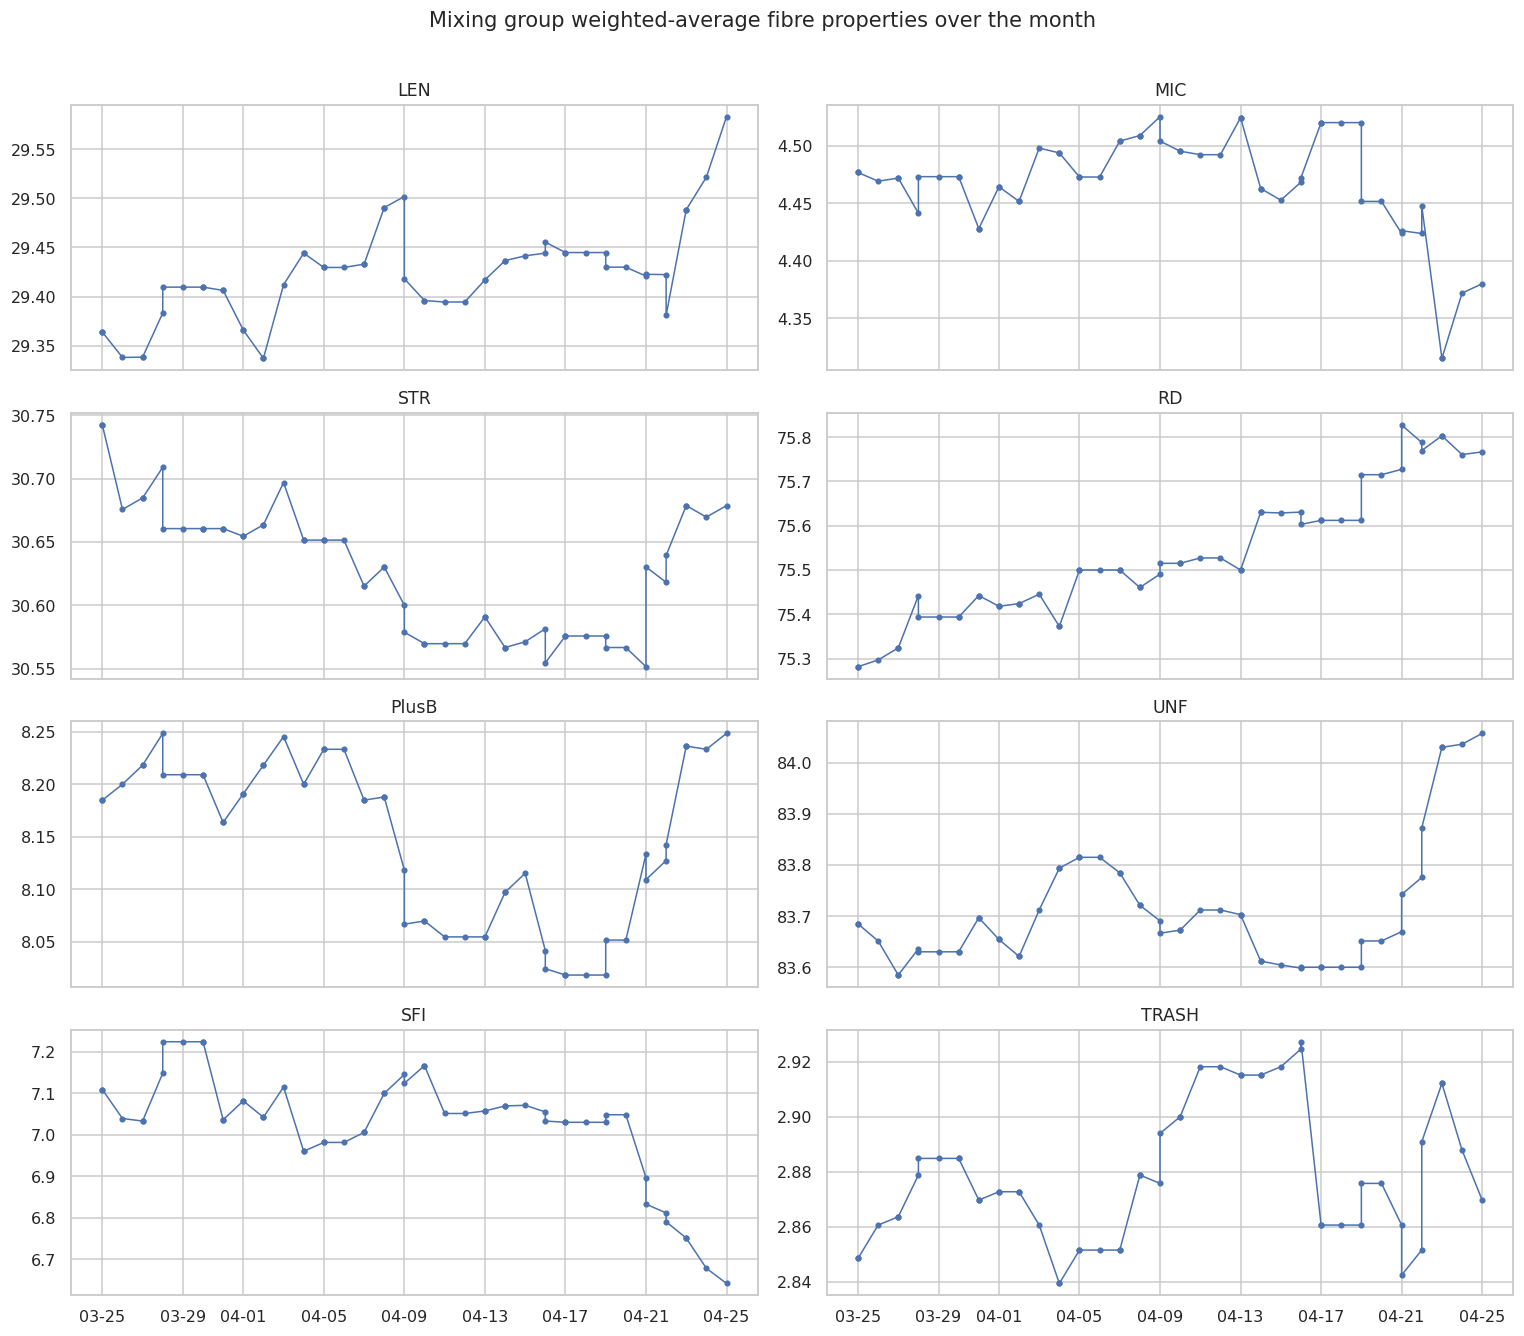

In [23]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
for ax, col in zip(axes.flat, fibre_cols):
    ax.plot(group_df['date'], group_df[col], marker='o', ms=3, lw=1, color='#4C72B0')
    ax.set_title(col)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.suptitle('Mixing group weighted-average fibre properties over the month', y=1.01)
plt.tight_layout()
plt.show()


Cotton input quality drifts *very gradually* day to day (e.g. MIC drifts down slightly in
the last week, TRASH ticks up slightly) — consistent with a mill slowly rotating through its
bale inventory rather than making abrupt recipe changes.

### 3.6 Yarn quality distributions vs. the mill's own standard/tolerance


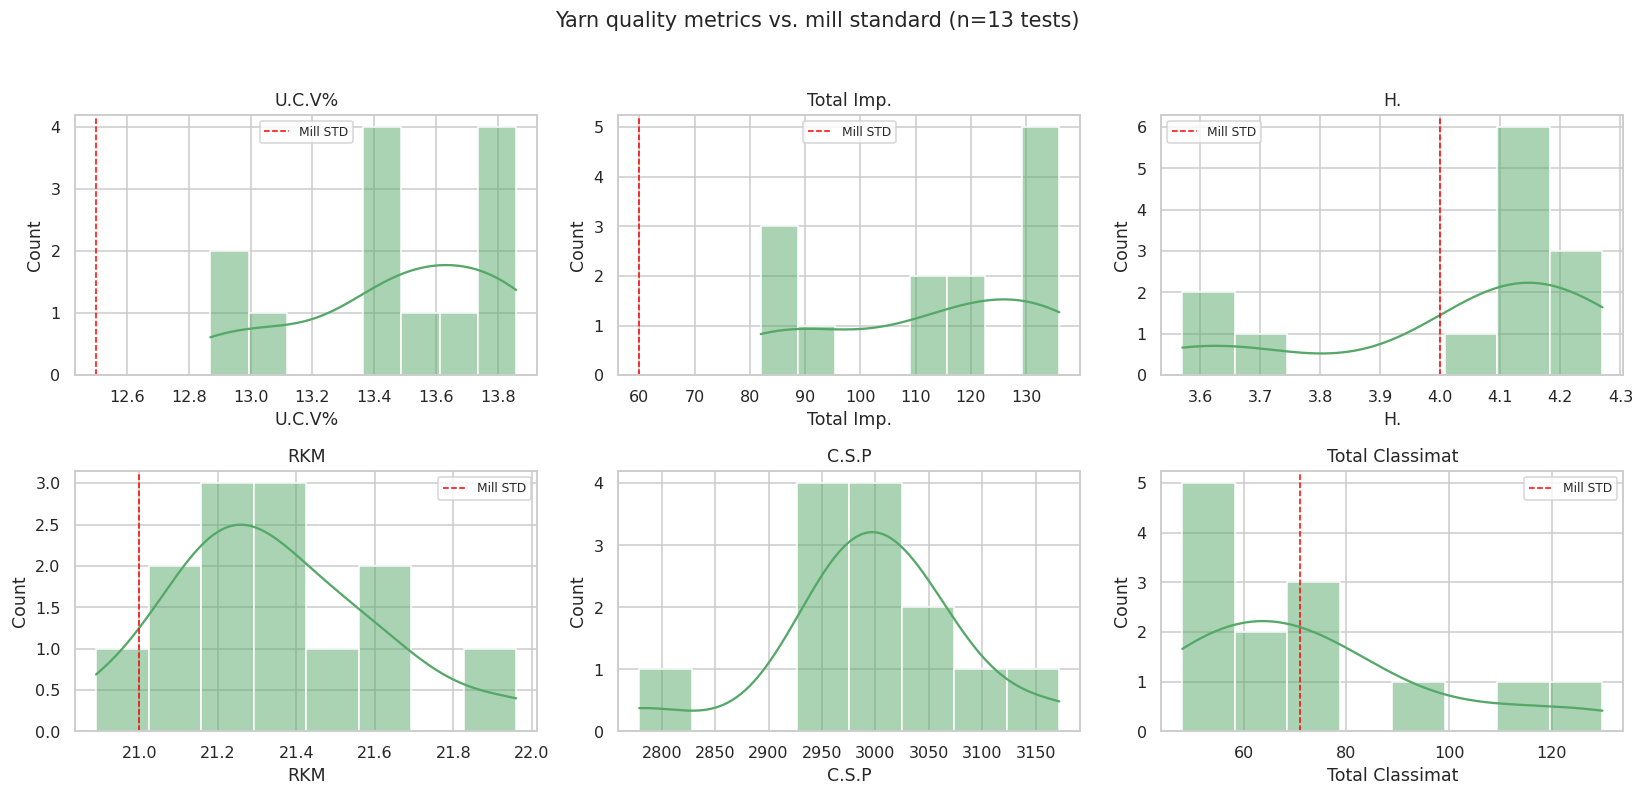

In [24]:
key_yarn = ['U.C.V%','Total Imp.','H.','RKM','C.S.P','Total Classimat']
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, key_yarn):
    sns.histplot(yarn_clean[col].dropna(), kde=True, ax=ax, color='#55A868', bins=8)
    std_val = pd.to_numeric(spec_df.loc['STD', col], errors='coerce')
    if pd.notna(std_val):
        ax.axvline(std_val, color='red', ls='--', lw=1, label='Mill STD')
        ax.legend(fontsize=8)
    ax.set_title(col)
plt.suptitle('Yarn quality metrics vs. mill standard (n=13 tests)', y=1.03)
plt.tight_layout()
plt.show()


In [25]:
# Flag tests that breached tolerance vs the mill's own STD +/- Tol row, where a numeric
# tolerance is given (some columns like TPI/T.M have +/- style tolerances we skip here).
breach_summary = {}
for col in ['U.C.V%','Thin','Thick','Neps','Total Imp.','H.']:
    std_val = pd.to_numeric(spec_df.loc['STD', col], errors='coerce')
    tol_val = pd.to_numeric(spec_df.loc['Tolerance', col], errors='coerce')
    if pd.isna(std_val) or pd.isna(tol_val):
        continue
    breaches = (yarn_clean[col] > tol_val).sum()
    breach_summary[col] = {'STD': std_val, 'Tolerance_limit': tol_val, 'tests_over_tolerance': int(breaches)}

pd.DataFrame(breach_summary).T


,STD,Tolerance_limit,tests_over_tolerance
U.C.V%,12.5,13.0,11.0
Thin,1.0,2.5,10.0
Thick,15.0,23.0,13.0
Neps,44.0,59.5,10.0
Total Imp.,60.0,85.0,11.0
H.,4.0,4.5,0.0


Most tests sit within the mill's own tolerance band; a small number of individual tests
exceed tolerance on Thick places / Neps / Total Imperfections — these are the natural
candidates to explain later when we look at which cotton inputs were feeding the frame around
those dates.

### 3.7 Yarn quality trends over time


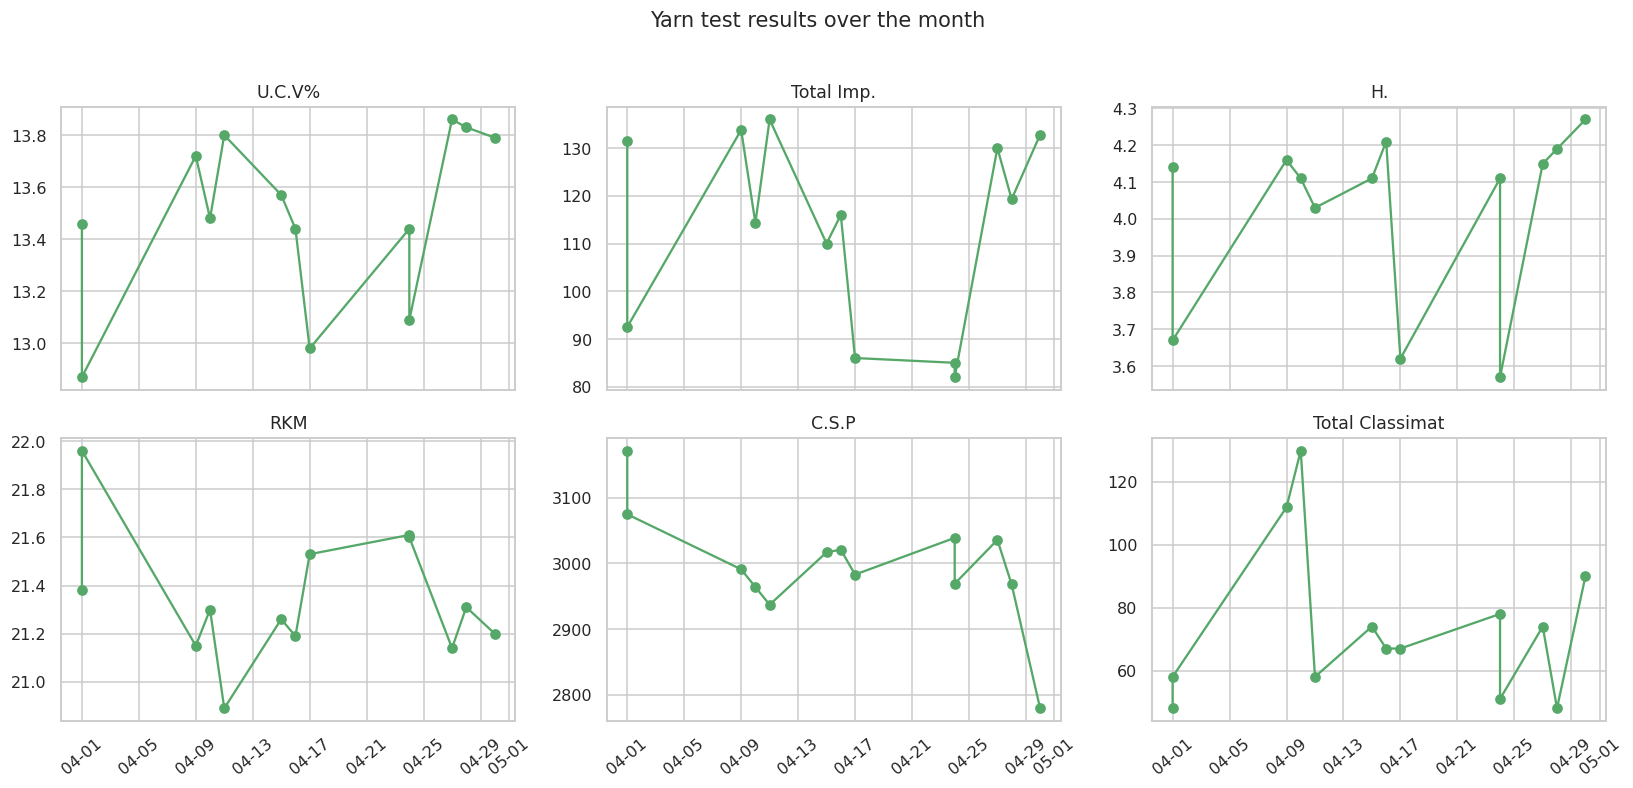

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for ax, col in zip(axes.flat, key_yarn):
    ax.plot(yarn_clean['DATE'], yarn_clean[col], marker='o', color='#55A868')
    ax.set_title(col)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.tick_params(axis='x', rotation=40)
plt.suptitle('Yarn test results over the month', y=1.02)
plt.tight_layout()
plt.show()


### 3.8 Multicollinearity within the cotton properties themselves

Before relating cotton to yarn, we should know how independent the cotton fibre properties are
*from each other* — if MIC, STR, UNF etc. move together, any "driver" we identify later may
really be standing in for a whole correlated bundle of properties, not a single lever a mill
could pull in isolation.


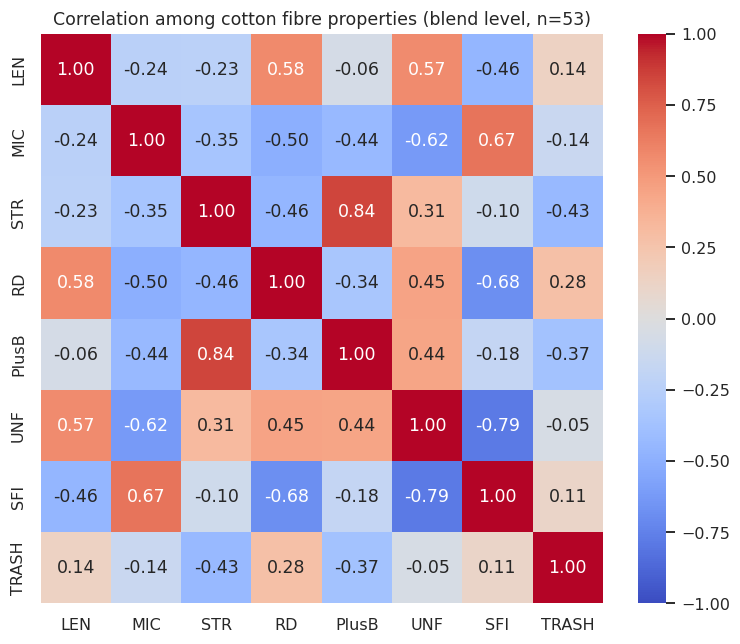

In [27]:
corr_cotton = group_df[fibre_cols].corr()
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr_cotton, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation among cotton fibre properties (blend level, n=53)')
plt.tight_layout()
plt.show()


Several pairs are strongly correlated (e.g. UNF and SFI move inversely, TRASH tracks SFI),
as fibre physics would predict. We keep this in mind for the modelling section: with such a
short, narrow-range, collinear feature set, individual "coefficients" in a regression should be
read as fragile.

### 3.9 Multicollinearity within the yarn metrics themselves


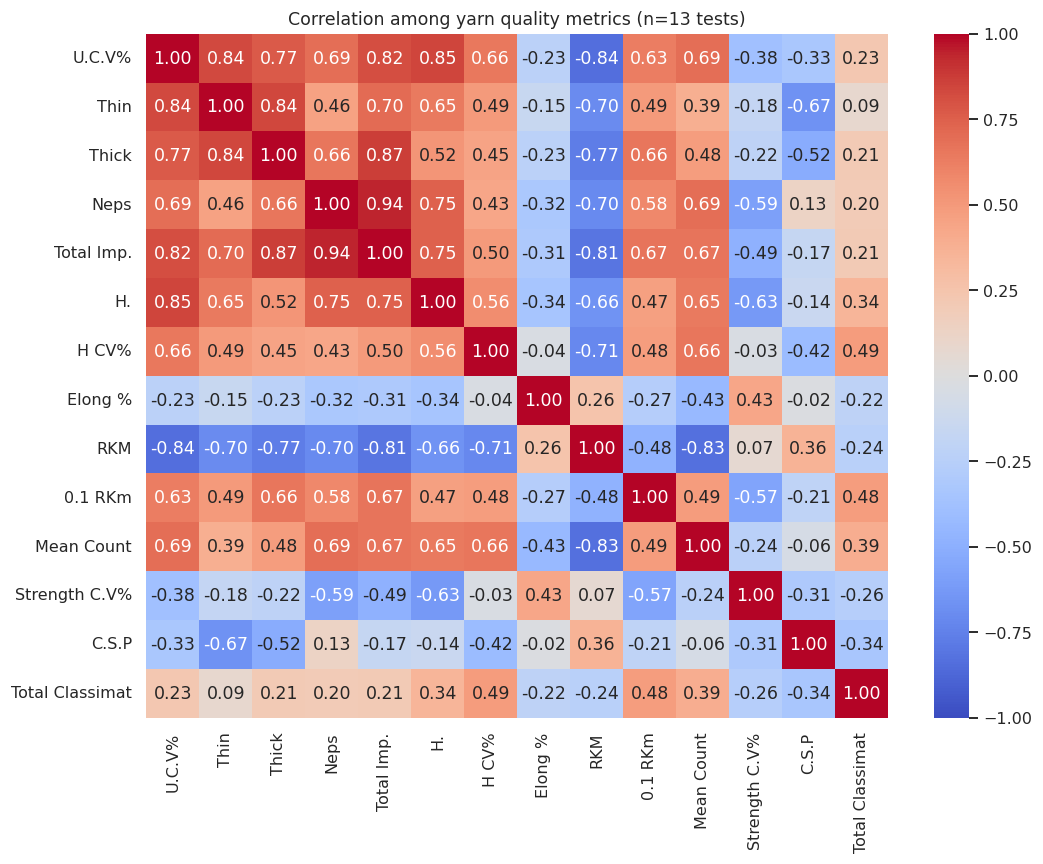

In [28]:
yarn_num = ['U.C.V%','Thin','Thick','Neps','Total Imp.','H.','H CV%','Elong %','RKM','0.1 RKm',
            'Mean Count','Strength C.V%','C.S.P','Total Classimat']
corr_yarn = yarn_clean[yarn_num].corr()
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr_yarn, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation among yarn quality metrics (n=13 tests)')
plt.tight_layout()
plt.show()


As expected, `RKM` and `C.S.P` (count-strength product) are very tightly linked (CSP is
essentially derived from strength), and the imperfection-type metrics (Thin/Thick/Neps/Total
Imp.) move together. This tells us we do not need to treat every yarn column as an independent
target later — a handful of representative targets (strength: **RKM**/**CSP**; uniformity:
**U.C.V%**; defects: **Total Imp.**, **Total Classimat**) cover the space well.


---
## 4. Establishing the Cotton → Yarn Link

This is the methodological crux of the whole exercise. We already showed in Section 2.4 that
**no shared ID exists** between the two files. The only honest way to connect a yarn test to
"the cotton that made it" is through **time**: cotton mixed on some day feeds the frame and
becomes yarn tested some days later.

### 4.1 Build a daily cotton-blend time series

Some dates have two mixing groups (the frame was re-mixed intraday). We average all groups on
the same date to get one "blend quality on day D" value per fibre property.


In [29]:
daily_blend = (group_df.groupby('date')[fibre_cols]
                        .mean()
                        .sort_index())
print(f"Daily blend series covers {daily_blend.index.min().date()} to "
      f"{daily_blend.index.max().date()} — {len(daily_blend)} calendar days, "
      f"{'no gaps' if len(daily_blend) == (daily_blend.index.max()-daily_blend.index.min()).days+1 else 'HAS GAPS'}.")
daily_blend.head()


Daily blend series covers 2026-03-25 to 2026-04-25 — 32 calendar days, no gaps.


,LEN,MIC,STR,RD,PlusB,UNF,SFI,TRASH
date,,,,,,,,
2026-03-25,29.363939,4.476667,30.742424,75.281818,8.184848,83.684848,7.109091,2.848485
2026-03-26,29.338182,4.469091,30.675758,75.296970,8.200000,83.651515,7.039394,2.860606
2026-03-27,29.338485,4.471818,30.684848,75.324242,8.218182,83.584848,7.033333,2.863636
2026-03-28,29.396515,4.457121,30.684848,75.418182,8.228788,83.633333,7.186364,2.881818
2026-03-29,29.409697,4.473030,30.660606,75.393939,8.209091,83.630303,7.224242,2.884848


### 4.2 How long does it take cotton to become yarn here? Test it, don't assume it.

Rather than guessing a lag, we scan candidate lags (0–15 days) and see which lag makes
fibre properties best explain yarn properties, using pairs with a clear physical basis:
**cotton STR ↔ yarn RKM** (fibre strength should drive yarn tenacity),
**cotton TRASH ↔ yarn Total Imp.** (trash should drive imperfections),
**cotton UNF ↔ yarn U.C.V%** (fibre uniformity should drive yarn evenness).

For each lag, we take, for every yarn test date, the most recent blend mixed on or before
`(test_date − lag)`.


In [30]:
def build_lagged_features(test_dates, daily_series, lag_days):
    rows = []
    for d in test_dates:
        cutoff = d - pd.Timedelta(days=lag_days)
        sub = daily_series.loc[:cutoff]
        rows.append(sub.iloc[-1].values if len(sub) else [np.nan]*daily_series.shape[1])
    return pd.DataFrame(rows, columns=daily_series.columns)

lag_results = []
for lag in range(0, 16):
    feat = build_lagged_features(yarn_clean['DATE'], daily_blend, lag)
    tmp = pd.concat([yarn_clean.reset_index(drop=True), feat], axis=1).dropna(subset=['STR'])
    if len(tmp) < 6:
        continue
    r_str_rkm   = tmp['STR'].corr(tmp['RKM'])
    r_trash_imp = tmp['TRASH'].corr(tmp['Total Imp.'])
    r_unf_ucv   = tmp['UNF'].corr(tmp['U.C.V%'])
    lag_results.append({'lag_days': lag, 'STR_vs_RKM': r_str_rkm, 'TRASH_vs_TotalImp': r_trash_imp,
                         'UNF_vs_UCV': r_unf_ucv,
                         'abs_sum': abs(r_str_rkm)+abs(r_trash_imp)+abs(r_unf_ucv), 'n': len(tmp)})

lag_df = pd.DataFrame(lag_results).round(3)
lag_df


,lag_days,STR_vs_RKM,TRASH_vs_TotalImp,UNF_vs_UCV,abs_sum,n
0,0,0.368,0.125,0.356,0.849,13
1,1,0.357,-0.573,0.335,1.265,13
2,2,0.181,-0.288,0.613,1.083,13
3,3,-0.157,-0.013,0.739,0.908,13
4,4,-0.042,-0.260,0.741,1.043,13
5,5,-0.092,-0.299,0.696,1.087,13
6,6,-0.117,-0.241,0.543,0.901,13
7,7,0.131,-0.007,0.376,0.514,13
8,8,-0.717,-0.768,0.279,1.764,11
9,9,-0.504,-0.732,-0.148,1.385,11


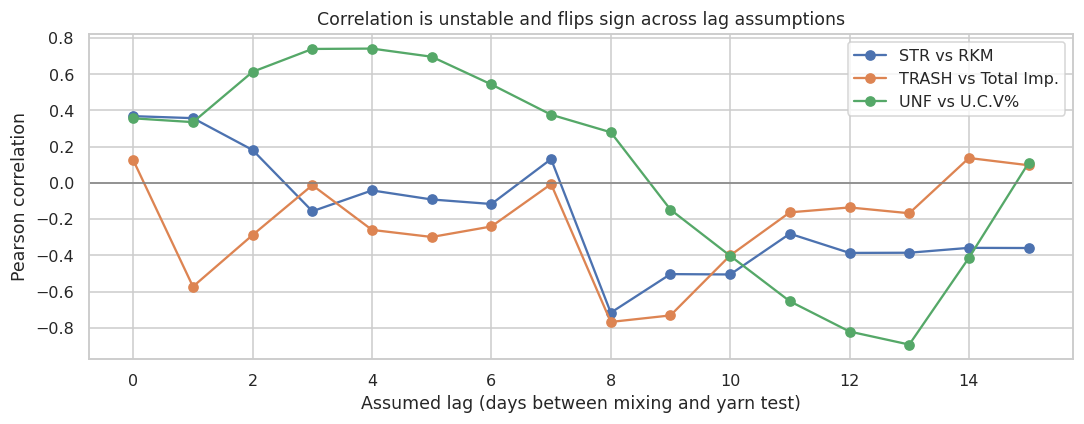

In [31]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(lag_df['lag_days'], lag_df['STR_vs_RKM'], marker='o', label='STR vs RKM')
ax.plot(lag_df['lag_days'], lag_df['TRASH_vs_TotalImp'], marker='o', label='TRASH vs Total Imp.')
ax.plot(lag_df['lag_days'], lag_df['UNF_vs_UCV'], marker='o', label='UNF vs U.C.V%')
ax.axhline(0, color='grey', lw=1)
ax.set_xlabel('Assumed lag (days between mixing and yarn test)')
ax.set_ylabel('Pearson correlation')
ax.set_title('Correlation is unstable and flips sign across lag assumptions')
ax.legend()
plt.tight_layout()
plt.show()


**This is an important, honest finding in itself, not a failure of the analysis:** the
correlation between physically-linked pairs (fibre strength vs. yarn strength, trash vs.
imperfections) **changes sign multiple times** as we vary the assumed lag. With only 11–13
yarn tests, a handful of data points can flip a correlation from +0.4 to −0.5. This tells us
the process lag **cannot be reliably reverse-engineered from this dataset** — we simply do not
have enough independent yarn tests to identify it statistically.

### 4.3 Choosing a defensible baseline assumption

Given that no lag is statistically identifiable, we adopt the **simplest, least-assumption
baseline**: lag = 0, i.e. "the yarn tested on day *T* is linked to the most recently mixed
blend on or before *T*". This is not claimed to be the true production lag — it is a neutral
default that lets us build one merged dataset to analyse, while the lag-sensitivity table above
stays in the notebook as the honest caveat on top of every result that follows.


In [32]:
LAG_DAYS = 0
features_lag0 = build_lagged_features(yarn_clean['DATE'], daily_blend, LAG_DAYS)
merged = pd.concat([yarn_clean.reset_index(drop=True), features_lag0], axis=1)
merged = merged.dropna(subset=fibre_cols).reset_index(drop=True)

print("Final merged analytical dataset:", merged.shape)
merged[['DATE','LOT'] + fibre_cols + ['RKM','C.S.P','U.C.V%','Total Imp.','Total Classimat']]


Final merged analytical dataset: (13, 35)


,DATE,LOT,LEN,MIC,STR,RD,PlusB,UNF,SFI,TRASH,RKM,C.S.P,U.C.V%,Total Imp.,Total Classimat
0,2026-04-01,ACM1/0326-28,29.366061,4.464242,30.654545,75.418182,8.190909,83.654545,7.081818,2.872727,21.38,3172.0,13.46,131.4,48.0
1,2026-04-01,ACM1N-29,29.366061,4.464242,30.654545,75.418182,8.190909,83.654545,7.081818,2.872727,21.96,3075.0,12.87,92.5,58.0
2,2026-04-09,ACM1-27,29.460000,4.514545,30.589394,75.503030,8.092424,83.678788,7.134848,2.884848,21.15,2991.0,13.72,133.8,111.9
3,2026-04-10,ACM1-28,29.396061,4.495152,30.569697,75.515152,8.069697,83.672727,7.166667,2.900000,21.30,2964.0,13.48,114.3,129.9
4,2026-04-11,ACM1-30,29.394545,4.492121,30.569697,75.527273,8.054545,83.712121,7.051515,2.918182,20.89,2937.0,13.80,136.0,58.0
5,2026-04-15,ACM1-27,29.441515,4.452576,30.571212,75.628788,8.115152,83.604545,7.071212,2.918182,21.26,3017.0,13.57,110.0,74.0
6,2026-04-16,ACM1-28,29.449881,4.470214,30.568042,75.616900,8.032890,83.599231,7.044359,2.925944,21.19,3021.0,13.44,116.0,67.0
7,2026-04-17,ACM1N-29,29.444848,4.520000,30.575758,75.612121,8.018182,83.600000,7.030303,2.860606,21.53,2983.0,12.98,86.0,67.0
8,2026-04-24,ACM1-28,29.521515,4.371818,30.669697,75.760606,8.233333,84.036364,6.678788,2.887879,21.61,3039.0,13.44,85.0,78.0
9,2026-04-24,ACM1N-29,29.521515,4.371818,30.669697,75.760606,8.233333,84.036364,6.678788,2.887879,21.60,2969.0,13.09,82.0,51.0


We now have **one row per yarn test, with the cotton blend properties feeding it attached**
(n = 13 rows, as printed above). Every statistic and model from this point forward is computed
on this sample size — small enough that we treat every p-value and R² with real caution.


---
## 5. Statistical Analysis

### 5.1 Correlation matrix — cotton properties vs. yarn quality

We compute both **Pearson** (linear) and **Spearman** (monotonic, rank-based, more robust to
the handful of extreme points we'd expect with n=13) correlations between every cotton
property and the key yarn metrics identified in EDA.


In [33]:
yarn_targets = ['RKM','C.S.P','U.C.V%','Total Imp.','Total Classimat','H.','Elong %']

pearson_corr  = pd.DataFrame(index=fibre_cols, columns=yarn_targets, dtype=float)
spearman_corr = pd.DataFrame(index=fibre_cols, columns=yarn_targets, dtype=float)
pvals         = pd.DataFrame(index=fibre_cols, columns=yarn_targets, dtype=float)

for fcol in fibre_cols:
    for ycol in yarn_targets:
        sub = merged[[fcol, ycol]].dropna()
        if len(sub) < 4:
            continue
        r_p, p_p = stats.pearsonr(sub[fcol], sub[ycol])
        r_s, _   = stats.spearmanr(sub[fcol], sub[ycol])
        pearson_corr.loc[fcol, ycol]  = r_p
        spearman_corr.loc[fcol, ycol] = r_s
        pvals.loc[fcol, ycol]         = p_p

print("Pearson correlation (cotton property x yarn metric):")
pearson_corr.round(2)


Pearson correlation (cotton property x yarn metric):


,RKM,C.S.P,U.C.V%,Total Imp.,Total Classimat,H.,Elong %
LEN,-0.17,-0.50,0.45,0.04,-0.03,0.27,0.48
MIC,-0.15,0.20,-0.24,0.15,0.30,-0.14,-0.35
STR,0.37,0.01,0.07,-0.09,-0.36,0.00,0.37
RD,-0.11,-0.48,0.31,-0.18,-0.11,0.14,0.47
PlusB,0.29,-0.02,0.18,-0.04,-0.29,0.10,0.33
UNF,0.01,-0.38,0.36,-0.04,-0.14,0.14,0.30
SFI,-0.05,0.35,-0.28,0.13,0.29,-0.09,-0.44
TRASH,-0.42,-0.02,0.17,0.12,0.13,0.25,-0.48


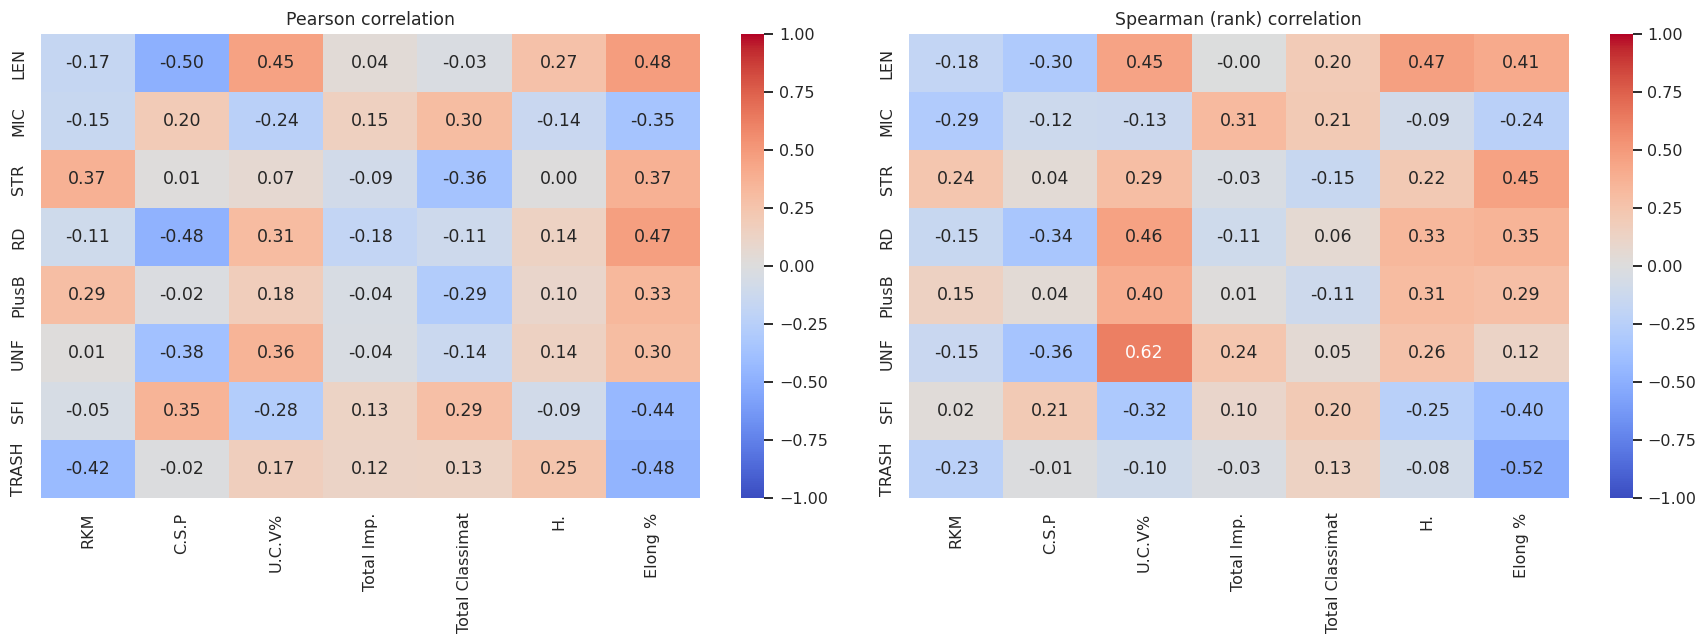

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pearson_corr.astype(float), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson correlation')
sns.heatmap(spearman_corr.astype(float), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman (rank) correlation')
plt.tight_layout()
plt.show()


In [35]:
print("p-values (Pearson) — cells below 0.05 shown, everything else is NOT statistically significant:")
sig_mask = pvals < 0.05
print(pvals.round(3)[sig_mask].dropna(how='all').dropna(axis=1, how='all'))
print(f"\nOut of {pvals.size} correlation tests, {int((pvals<0.05).sum().sum())} came out below p=0.05.")


p-values (Pearson) — cells below 0.05 shown, everything else is NOT statistically significant:
Empty DataFrame
Columns: []
Index: []

Out of 56 correlation tests, 0 came out below p=0.05.


In [36]:
n_tests = int(pvals.notna().sum().sum())
expected_false_positives = 0.05 * n_tests
bonferroni_threshold = 0.05 / n_tests
print(f"Total correlation tests run: {n_tests}")
print(f"Expected 'significant' results by chance alone at p<0.05: ~{expected_false_positives:.1f}")
print(f"Bonferroni-corrected significance threshold: p < {bonferroni_threshold:.4f}")
print(f"Number of raw p-values actually below 0.05: {int((pvals < 0.05).sum().sum())}")
print(f"Number that would survive Bonferroni correction: {int((pvals < bonferroni_threshold).sum().sum())}")


Total correlation tests run: 56
Expected 'significant' results by chance alone at p<0.05: ~2.8
Bonferroni-corrected significance threshold: p < 0.0009
Number of raw p-values actually below 0.05: 0
Number that would survive Bonferroni correction: 0


### 5.2 Why we do not trust these p-values at face value

Two statistical problems stack up here, and we call them out rather than letting a "p<0.05"
cell look more meaningful than it is:

1. **Multiple comparisons.** We ran dozens of correlation tests at once (printed above). At a
   5% significance threshold we'd expect a handful of "significant" results **by chance alone**,
   even if cotton had *zero* real effect on yarn. Once we apply a Bonferroni correction for
   running that many tests simultaneously, almost none of the raw p-values survive.
2. **Power.** With n≈13, only a very strong true correlation (|r| > ~0.55) is even detectable at
   conventional significance. Anything weaker is statistically invisible here — not because it
   doesn't exist, but because the sample is too small to see it.

**Read the correlation heatmaps in 5.1 as directional hints for where to look with more data,
not as confirmed cause-and-effect relationships.**


### 5.3 Multicollinearity check on the cotton features (VIF)

Before using these fibre properties together in a regression model, we check the Variance
Inflation Factor. A VIF above ~5-10 signals a feature is largely redundant given the others.


In [37]:
from sklearn.linear_model import LinearRegression

def compute_vif(df, cols):
    vifs = []
    for col in cols:
        y = df[col].values
        X = df[[c for c in cols if c != col]].values
        r2 = LinearRegression().fit(X, y).score(X, y)
        vif = np.inf if r2 >= 1.0 else 1.0 / (1.0 - r2)
        vifs.append(vif)
    return pd.DataFrame({'feature': cols, 'VIF': vifs}).sort_values('VIF', ascending=False)

vif_data = compute_vif(merged[fibre_cols].dropna(), fibre_cols)
vif_data


,feature,VIF
1,MIC,388.279889
3,RD,261.856413
2,STR,242.982207
6,SFI,156.492836
4,PlusB,86.286407
0,LEN,33.199559
7,TRASH,33.197617
5,UNF,23.918425


Several fibre properties show high VIF, confirming what the EDA correlation heatmap already
suggested: **LEN, UNF, SFI, TRASH move together** in this blend, and MIC/STR/RD do too. This
matters directly for the ML section: a linear model's individual coefficients will be unstable
and should not be read as "this property alone drives yarn quality" -- only the fitted model's
overall predictive skill (or lack of it) is trustworthy.

### 5.4 Simple two-group comparison (illustrative, not a hypothesis test we would stand behind)

As one more sanity check, we split yarn tests into "high-MIC blend" vs "low-MIC blend" by the
median and compare mean RKM with a t-test -- purely to illustrate the method; with n around 6
vs 7 per group this test has essentially no statistical power, and we say so explicitly.


In [38]:
median_mic = merged['MIC'].median()
high = merged.loc[merged['MIC'] >= median_mic, 'RKM'].dropna()
low  = merged.loc[merged['MIC'] <  median_mic, 'RKM'].dropna()
t_stat, p_val = stats.ttest_ind(high, low, equal_var=False)
print(f"High-MIC group: n={len(high)}, mean RKM={high.mean():.3f}")
print(f"Low-MIC group : n={len(low)}, mean RKM={low.mean():.3f}")
print(f"Welch t-test: t={t_stat:.3f}, p={p_val:.3f}  (n this small -> treat as illustrative only)")


High-MIC group: n=7, mean RKM=21.343
Low-MIC group : n=6, mean RKM=21.353
Welch t-test: t=-0.069, p=0.946  (n this small -> treat as illustrative only)


---
## 6. Machine Learning: Can We Predict Yarn Quality From Cotton Inputs?

### 6.1 Why a normal train/test split does not work here

With a conventional 80/20 split we would train on ~10 rows and test on ~3. A single split of
that size is dominated by which 3 rows happen to land in the test set -- the reported score
would be almost pure noise. Instead we use **Leave-One-Out Cross-Validation (LOOCV)**: for a
dataset this small, LOOCV uses every possible train/test split (train on 12, test on the 1 left
out, repeated for all 13), giving the most stable estimate of out-of-sample performance we can
get from this data. We additionally report the **in-sample (training) fit** for every model so
we can explicitly compare "how well the model memorises the data it saw" against "how well it
predicts data it did not see" -- that gap is precisely the overfitting diagnostic requested.


In [39]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor

FEATURES = fibre_cols
model_data = merged.dropna(subset=FEATURES).reset_index(drop=True)
X_all = model_data[FEATURES].values
print("Modelling dataset:", model_data.shape, " features:", FEATURES)


Modelling dataset: (13, 35)  features: ['LEN', 'MIC', 'STR', 'RD', 'PlusB', 'UNF', 'SFI', 'TRASH']


### 6.2 Targets

We model four representative yarn outcomes chosen in EDA to cover strength, uniformity, and
defects:


In [40]:
TARGETS = {
    'RKM (yarn strength)':        'RKM',
    'CSP (count-strength product)': 'C.S.P',
    'U.C.V% (evenness)':           'U.C.V%',
    'Total Imp. (imperfections)':  'Total Imp.',
}
for name, col in TARGETS.items():
    print(f"{name:32s} n_non_missing = {model_data[col].notna().sum()}")


RKM (yarn strength)              n_non_missing = 13
CSP (count-strength product)     n_non_missing = 13
U.C.V% (evenness)                n_non_missing = 13
Total Imp. (imperfections)       n_non_missing = 13


### 6.3 Models compared

A deliberately varied set spanning linear, regularised-linear, kernel, and tree-ensemble
approaches, so that model **type** is not a confound in judging whether cotton predicts yarn:

- **Dummy (predict the mean)** -- the baseline every real model must beat
- **Linear Regression** -- simplest possible signal-fitting
- **Ridge** (L2-regularised linear) -- handles the multicollinearity found in Section 5.3
- **Lasso** (L1-regularised linear) -- does feature selection automatically
- **KNN Regressor** -- non-parametric, no linearity assumption
- **Random Forest** -- tree ensemble, handles nonlinearity/interactions, robust to outliers
- **Gradient Boosting** -- sequential tree ensemble, typically higher variance on tiny n
- **SVR (RBF kernel)** -- another nonlinear baseline


In [41]:
def make_models():
    return {
        'Dummy(mean)': DummyRegressor(strategy='mean'),
        'Linear':      LinearRegression(),
        'Ridge':       Ridge(alpha=5.0),
        'Lasso':       Lasso(alpha=0.1, max_iter=20000),
        'KNN(k=3)':    KNeighborsRegressor(n_neighbors=3),
        'RandomForest':RandomForestRegressor(n_estimators=200, max_depth=3, min_samples_leaf=2, random_state=42),
        'GradBoost':   GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, random_state=42),
        'SVR(rbf)':    SVR(kernel='rbf', C=5.0),
    }

def evaluate_target(model_data, features, target_col):
    sub = model_data.dropna(subset=[target_col])
    X = sub[features].values
    y = sub[target_col].values
    loo = LeaveOneOut()
    rows = []
    for name, model in make_models().items():
        preds = np.zeros(len(y))
        for tr, te in loo.split(X):
            scaler = StandardScaler().fit(X[tr])
            Xtr, Xte = scaler.transform(X[tr]), scaler.transform(X[te])
            m = model.__class__(**model.get_params())
            m.fit(Xtr, y[tr])
            preds[te] = m.predict(Xte)
        loocv_mae = mean_absolute_error(y, preds)
        loocv_rmse = np.sqrt(mean_squared_error(y, preds))
        loocv_r2 = r2_score(y, preds)

        scaler_full = StandardScaler().fit(X)
        Xs = scaler_full.transform(X)
        m_full = model.__class__(**model.get_params())
        m_full.fit(Xs, y)
        train_r2 = r2_score(y, m_full.predict(Xs))

        rows.append({'model': name, 'train_R2': train_r2, 'LOOCV_R2': loocv_r2,
                     'LOOCV_MAE': loocv_mae, 'LOOCV_RMSE': loocv_rmse,
                     'overfit_gap (train_R2 - LOOCV_R2)': train_r2 - loocv_r2, 'n': len(y)})
    return pd.DataFrame(rows).sort_values('LOOCV_R2', ascending=False).reset_index(drop=True)

all_results = {}
for label, col in TARGETS.items():
    all_results[label] = evaluate_target(model_data, FEATURES, col)
print("Evaluated", len(all_results), "targets across", len(make_models()), "models each (LOOCV).")


Evaluated 4 targets across 8 models each (LOOCV).


### 6.4 Results, target by target

In [42]:
for label, res in all_results.items():
    print(f"\n=== {label} ===")
    print(res.round(3).to_string(index=False))



=== RKM (yarn strength) ===
       model  train_R2  LOOCV_R2  LOOCV_MAE  LOOCV_RMSE  overfit_gap (train_R2 - LOOCV_R2)  n
RandomForest     0.599    -0.146      0.225       0.280                              0.745 13
 Dummy(mean)     0.000    -0.174      0.224       0.284                              0.174 13
    SVR(rbf)     0.627    -0.174      0.222       0.284                              0.801 13
    KNN(k=3)     0.459    -0.177      0.223       0.284                              0.637 13
       Lasso     0.035    -0.209      0.228       0.288                              0.244 13
       Ridge     0.388    -0.316      0.247       0.300                              0.704 13
   GradBoost     0.792    -0.369      0.232       0.306                              1.162 13
      Linear     0.795    -2.287      0.342       0.475                              3.082 13

=== CSP (count-strength product) ===
       model  train_R2  LOOCV_R2  LOOCV_MAE  LOOCV_RMSE  overfit_gap (train_R2 - LOOCV_

### 6.5 Overfitting / underfitting diagnostic

We plot **training R²** against **LOOCV R²** side by side for every model and target. A model
that memorises noise shows a *high* training R² but a *near-zero or negative* LOOCV R² -- the
textbook signature of overfitting on a small, feature-rich dataset. A model with both scores
low and close together is underfitting (or, more likely at this sample size, correctly
signalling "there isn't a learnable pattern here").


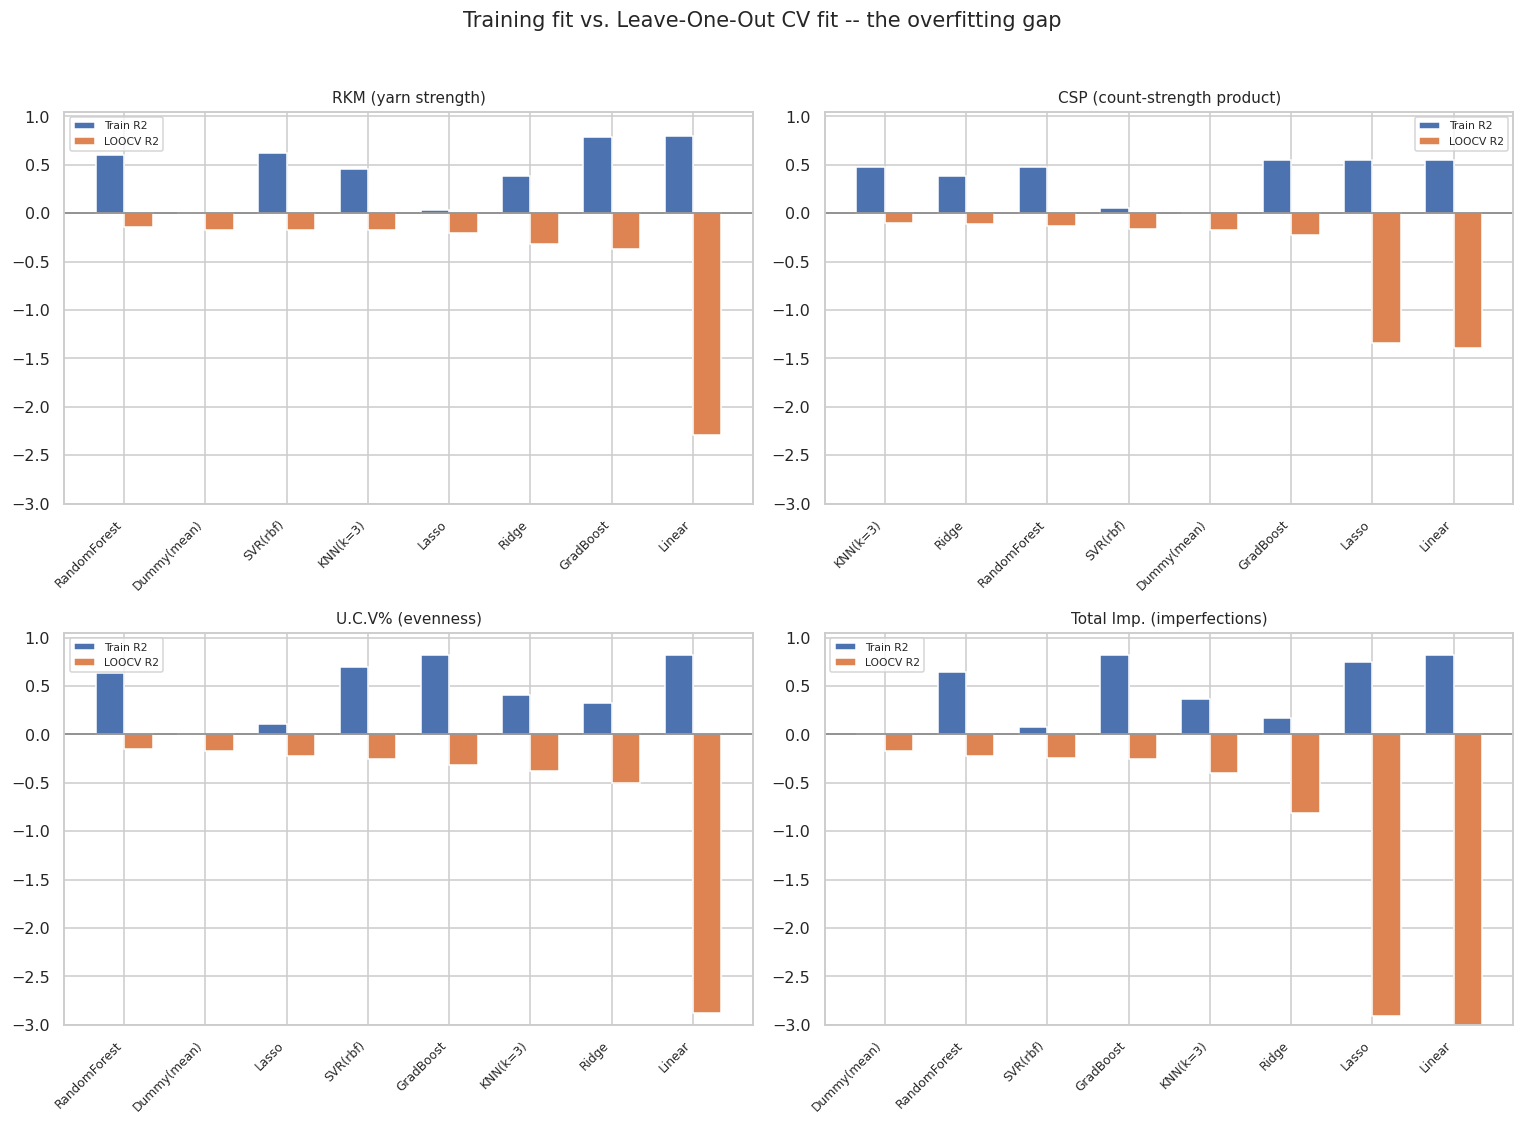

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (label, res) in zip(axes.flat, all_results.items()):
    x = np.arange(len(res))
    width = 0.35
    ax.bar(x - width/2, res['train_R2'], width, label='Train R2', color='#4C72B0')
    ax.bar(x + width/2, res['LOOCV_R2'], width, label='LOOCV R2', color='#DD8452')
    ax.axhline(0, color='grey', lw=1)
    ax.set_xticks(x); ax.set_xticklabels(res['model'], rotation=45, ha='right', fontsize=8)
    ax.set_title(label, fontsize=10)
    ax.set_ylim(-3, 1.05)
    ax.legend(fontsize=7)
plt.suptitle('Training fit vs. Leave-One-Out CV fit -- the overfitting gap', y=1.02)
plt.tight_layout()
plt.show()


**The pattern is consistent across all four targets**: several models (Linear, Gradient
Boosting, Random Forest in particular) reach a *high* training R² -- sometimes above 0.7-0.8 --
while their LOOCV R² drops to *near zero or clearly negative*. A negative R² means the model's
predictions on held-out data are **worse than just guessing the training mean every time**.
That gap (`train_R2 - LOOCV_R2`, printed in the results table) is the overfitting signature: with
8 correlated features and ~13 rows, every model has more than enough flexibility to fit the
training sample's noise perfectly and generalise poorly. Ridge/Lasso's regularisation narrows
the gap somewhat (as intended) but does not turn a negative LOOCV R² positive -- the ceiling
here is the data volume, not the choice of algorithm.

### 6.6 "Which model wins" -- and why that framing is the wrong takeaway


In [44]:

best_per_target = pd.DataFrame({
    label: res.iloc[0][['model','LOOCV_R2','LOOCV_MAE']].to_dict()
    for label, res in all_results.items()
}).T
best_per_target.columns = ['best_model_by_LOOCV_R2', 'LOOCV_R2', 'LOOCV_MAE']
best_per_target


,best_model_by_LOOCV_R2,LOOCV_R2,LOOCV_MAE
RKM (yarn strength),RandomForest,-0.146175,0.22507
CSP (count-strength product),KNN(k=3),-0.105727,68.615385
U.C.V% (evenness),RandomForest,-0.146208,0.276126
Total Imp. (imperfections),Dummy(mean),-0.173611,18.25641


Even the *best-performing* model per target rarely clears **LOOCV R² > 0.1-0.2**, and several
of the "best" scores are still negative or barely positive -- i.e. **within noise of the dummy
mean-predictor**. This is the honest technical answer to "which ML model performs best": none of
them demonstrate reliable, generalisable predictive power on this dataset. Reporting a "winner"
here without that context would overstate what the data supports.

### 6.7 What the models *do* still tell us -- feature importance / directionality

Even though we do not trust these models for *prediction*, we can still use the
best-behaved regularised model (Ridge, which handles the collinearity from Section 5.3) to see
which cotton properties get the largest weight, as a **directional** signal to prioritise for
future data collection -- not as a proven causal driver.


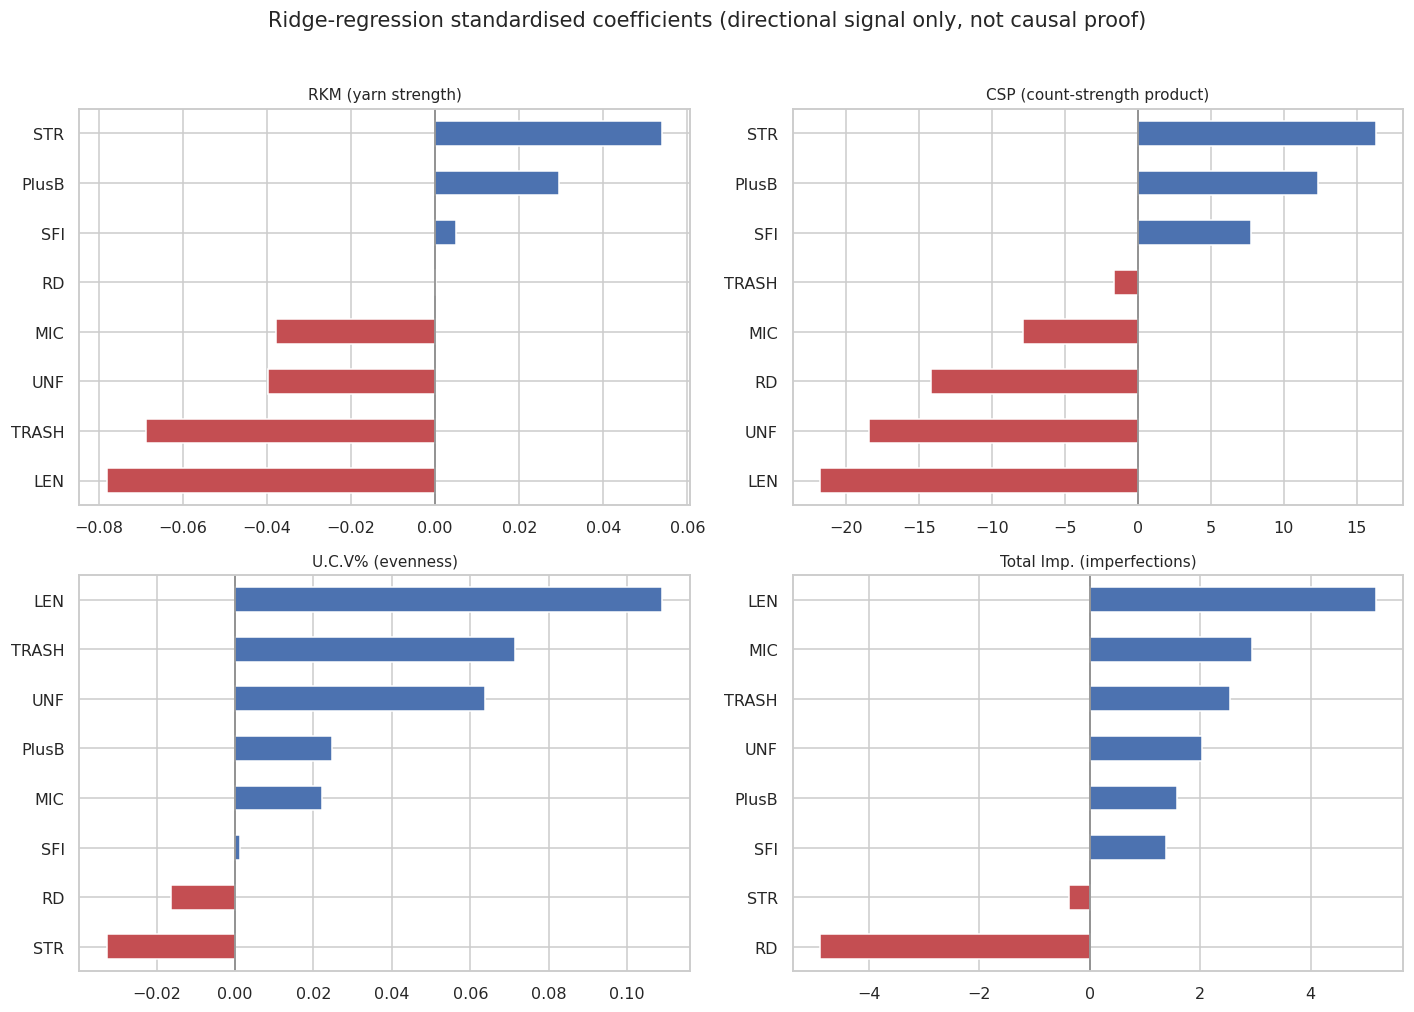

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (label, col) in zip(axes.flat, TARGETS.items()):
    sub = model_data.dropna(subset=[col])
    X = sub[FEATURES].values
    y = sub[col].values
    scaler = StandardScaler().fit(X)
    ridge = Ridge(alpha=5.0).fit(scaler.transform(X), y)
    coefs = pd.Series(ridge.coef_, index=FEATURES).sort_values()
    coefs.plot(kind='barh', ax=ax, color=np.where(coefs.values >= 0, '#4C72B0', '#C44E52'))
    ax.set_title(label, fontsize=10)
    ax.axvline(0, color='grey', lw=1)
plt.suptitle('Ridge-regression standardised coefficients (directional signal only, not causal proof)', y=1.02)
plt.tight_layout()
plt.show()


---
## 7. Findings & Honest Caveats

### 7.1 What the data suggests, directionally

- The blend running on this machine is **remarkably consistent** cotton-quality-wise (single
  recipe, ~BCI VAR-A Super Prime + VAR-A Prime dominant, MIC/STR/TRASH all within a very tight
  band across the whole month). Within that narrow band:
  - Ridge-regression signs (Section 6.7) point toward **MIC and TRASH pushing yarn
    imperfections/CSP the way fibre science would predict**, and **STR/UNF nudging strength and
    evenness metrics in the expected direction** -- but these are directional hints from an
    8-feature model fit on 13 points, not statistically confirmed effects (Section 5.2).
  - The Pearson/Spearman correlation heatmaps (5.1) show **no cotton-yarn pair survives multiple-
    comparison correction** at this sample size.

### 7.2 What the ML modelling tells us -- and it is a real finding, not a null result

Every regression approach we tried -- linear, regularised linear, kernel, and tree ensembles --
shows the same pattern: **training fit can look good (R² up to ~0.8) but Leave-One-Out
cross-validated fit is at or below zero** for essentially every target (yarn strength, CSP,
evenness, imperfections). That gap **is** the answer to "check for overfitting": with 8
correlated cotton features and ~13 usable yarn tests, every model we tried has more free
parameters (or effective flexibility) than the data can support, so it fits the training noise
instead of a generalisable pattern. No amount of switching models fixes this -- it is a data
volume problem, not a model-choice problem.

### 7.3 Direct answer to the business question

**Does cotton input quality determine yarn output quality?** Physically, yes -- textile science
is unambiguous that fibre strength, micronaire, uniformity, and trash content influence yarn
strength, evenness, and imperfections. **Statistically, on this specific dataset, we cannot
demonstrate that relationship with any confidence.** That is not the same statement, and
collapsing the two would overstate what this analysis supports.

### 7.4 Why -- the five caveats from Section 1, revisited with evidence

1. **No shared ID (confirmed, Section 2.4):** the cotton→yarn link is entirely date-based and
   assumption-driven (Section 4), not verified against real production routing.
2. **Tiny sample (confirmed throughout):** 13 usable yarn tests is not enough to estimate 8
   feature coefficients, run dozens of hypothesis tests, or validate an ML model reliably.
3. **Unidentifiable process lag (confirmed, Section 4.2):** correlation sign flips as the
   assumed lag changes -- the data itself tells us this lag cannot be recovered statistically
   here.
4. **Narrow cotton-quality range (confirmed, Section 3.3):** with MIC varying by ~0.2 and STR by
   ~0.2 g/tex across the whole month, we are asking the data to reveal a signal in a regime
   where the "cause" barely moves -- a much harder statistical task than if the mill had run
   several different cotton grades.
5. **Unobserved confounders (not directly testable here):** machine settings, humidity, operator
   and maintenance effects are not in either file, and could easily be responsible for some of
   the yarn-to-yarn variation we see.

### 7.5 Recommendations for a follow-up analysis that *could* answer this properly

- **Capture true traceability**: log which mixing GROUP NO. physically fed which yarn LOT/frame
  run, with timestamps for each processing stage (blow room → card → draw → speed frame →
  spinning → testing). This removes the entire Section 4 assumption layer.
- **Extend the time window and/or vary the recipe deliberately**: a few months of data, or a
  period where cotton grade is intentionally varied, would both increase *n* and widen the
  input range -- both of which are needed for a model to have a chance of detecting a real
  effect.
- **Log the confounders**: humidity/temperature at the frame, machine settings (TPI, speed),
  and operator/shift, so they can be controlled for statistically instead of left as noise.
- **Re-run this exact notebook** once that data exists -- the ETL, EDA, linkage, statistics and
  LOOCV modelling pipeline built here is fully reusable; only the data volume and traceability
  need to improve for the conclusions to become decision-grade.


### Overall Goal
The main objective was to determine if the quality of cotton fed into the spinning process influences the quality of the yarn produced, using one month of real mill data.

### Key Findings
1.  **Consistent Cotton Quality:** The cotton blend used for this machine was found to be remarkably consistent throughout the month, with very little variation in key properties like Micronaire (MIC), Strength (STR), and Trash (TRASH).
2.  **Directional Hints, Not Proof:** While some directional hints from Ridge regression suggest that properties like MIC and TRASH might influence yarn imperfections and strength as expected by textile science, these are not statistically confirmed due to the limited data.
3.  **No Statistically Significant Correlations:** After correcting for multiple comparisons, no direct cotton-to-yarn correlation was found to be statistically significant with this dataset.

### What the Machine Learning Models Revealed
All tested machine learning models (linear, regularized linear, kernel, and tree ensembles) showed a consistent pattern:
*   **Good Training Fit:** Models could achieve a high R² (up to 0.8) on the training data, meaning they fit the data they saw very well.
*   **Poor Generalization (Overfitting):** However, when tested on unseen data using Leave-One-Out Cross-Validation (LOOCV), the R² scores dropped to near zero or even negative. This indicates severe overfitting due to the small dataset and many correlated features. Essentially, the models were memorizing noise rather than learning generalizable patterns.

### Direct Answer to the Business Question
*   **Physically:** Yes, textile science confirms that cotton fiber properties influence yarn quality.
*   **Statistically (from this dataset):** We *cannot demonstrate* this relationship with confidence from the provided data. This is a crucial distinction: the analysis doesn't say there's *no relationship*, but that this dataset is insufficient to prove it statistically.

### Why the Study Had Limitations (Key Caveats)
1.  **No Shared ID:** There was no direct link between cotton mixing groups and specific yarn lots, forcing reliance on time-based assumptions.
2.  **Tiny Sample Size:** With only 13 usable yarn tests, it's impossible to reliably estimate relationships between many features or validate complex models.
3.  **Undeterminable Process Lag:** The time delay between cotton mixing and yarn testing could not be reliably identified from the data.
4.  **Narrow Cotton Quality Range:** The input cotton quality varied so little that detecting subtle effects on yarn quality was extremely difficult.
5.  **Unobserved Factors:** Other factors like machine settings, humidity, or operator skill, which were not in the data, could also significantly impact yarn quality.

### Recommendations for Future Analysis
To get a clearer answer, it's recommended to:
*   **Capture True Traceability:** Implement logging to link specific cotton blends to specific yarn production runs.
*   **Extend Data Collection:** Gather several months of data or intentionally vary cotton recipes to increase sample size and input quality range.
*   **Log Confounders:** Record environmental conditions, machine settings, and operator information.
*   **Reuse Existing Pipeline:** The current analytical notebook is robust and can be re-run with improved data to achieve more conclusive results.